# BAB 4 — Logika Tabel dan Gambar Terbuka

Seluruh logika khusus BAB 4 berada langsung di notebook ini. Notebook hanya membaca data sumber,
menampilkan tabel sebagai DataFrame, dan merender gambar inline. Tidak ada CSV, PNG, manifest,
maupun narasi Markdown yang ditulis ke disk.

## Setup dan utilitas bersama

In [1]:
%matplotlib inline

from collections import defaultdict
from decimal import Decimal, ROUND_HALF_UP
from pathlib import Path
from textwrap import dedent
import json
import math
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from osgeo import gdal

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from bab4.artifacts import ALL_ARTIFACTS, ArtifactSpec
from bab4.common import (
    CHANNELS_7CH, CV_REGIONS, MODEL_KEYS, MODEL_LABELS, REGIONS,
    SPATIAL_CV_FOLDS, TEST_REGION, fmt_float, pct, read_csv_row_map,
    read_csv_rows, to_float, to_int,
)
from bab4.config import Bab4Config
from bab4.plots import hsv_to_display_rgb, normalize_image, setup_style
from bab4.raster import (
    boolean_mask_counts, load_npz, masked_band_stats, open_dataset,
    raster_metadata, read_raster, read_stack_rgb,
)

config = Bab4Config.from_repo(ROOT, clean_outputs=False)

In [2]:
SPEC_BY_FILENAME = {spec.filename: spec for spec in ALL_ARTIFACTS}

def notebook_table(config, spec, rows, source=""):
    frame = pd.DataFrame(list(rows))
    display(Markdown(f"### {spec.artifact_id} — {spec.title}"))
    display(frame)
    return frame

def notebook_savefig(fig, path):
    spec = SPEC_BY_FILENAME.get(Path(path).name)
    if spec is not None:
        display(Markdown(f"### {spec.artifact_id} — {spec.title}"))
    display(fig)
    plt.close(fig)

def notebook_figure_result(config, spec, path, source=""):
    return spec

def notebook_missing(config, spec, source="", note=""):
    display(Markdown(f"> **{spec.artifact_id} tidak tersedia:** {note}"))
    return None

print(f"Repository: {ROOT}")
print("Mode: semua logika lokal, output inline, tanpa penulisan artefak")

Repository: /home/nozomi/Productive/skripsi
Mode: semua logika lokal, output inline, tanpa penulisan artefak


## 4.1.1 Statistik dan Visual Karakter Input

### Logika helper 4.1.1

In [3]:
def b411_spec(artifact_id: str):
    return next((spec for spec in ALL_ARTIFACTS if spec.artifact_id == artifact_id))

def b411_table_sentinel1(config):
    spec = b411_spec('Tabel 4.1')
    summary = read_csv_row_map(config.dataset_root / 'feature_preprocessing_summary.csv')
    rows = []
    for region in REGIONS:
        valid_pct = to_float(summary.get(region, {}).get('feature_valid_pct'))
        feature_dir = config.dataset_root / 'features_preprocessed' / region
        mask_path = feature_dir / 'feature_valid_mask.tif'
        vv_stats = masked_band_stats(feature_dir / 'vv_norm.tif', mask_path)
        vh_stats = masked_band_stats(feature_dir / 'vh_norm.tif', mask_path)
        rows.append({'wilayah': region.replace('_', ' '), 'mean_vv': fmt_float(vv_stats['mean']), 'std_vv': fmt_float(vv_stats['std']), 'mean_vh': fmt_float(vh_stats['mean']), 'std_vh': fmt_float(vh_stats['std']), 'piksel_valid_pct': fmt_float(valid_pct)})
    return notebook_table(config, spec, rows, source='dataset/features_preprocessed/*/{vv_norm.tif,vh_norm.tif,feature_valid_mask.tif}')

def b411_table_s2_valid(config):
    spec = b411_spec('Tabel 4.2')
    rows = []
    for region in REGIONS:
        feature_dir = config.dataset_root / 'features_preprocessed' / region
        counts = boolean_mask_counts(feature_dir / 's2_valid_mask.tif', feature_dir / 'feature_valid_mask.tif')
        s2_pct = pct(counts['true_count'], counts['total_count'])
        s2_in_feature_pct = pct(counts['intersection_count'], counts['mask_count'])
        feature_pct = pct(counts['mask_count'], counts['total_count'])
        rows.append({'wilayah': region.replace('_', ' '), 's2_valid_terhadap_raster_pct': fmt_float(s2_pct), 's2_valid_dalam_feature_valid_pct': fmt_float(s2_in_feature_pct), 'feature_valid_pct': fmt_float(feature_pct)})
    return notebook_table(config, spec, rows, source='dataset/features_preprocessed/*/{s2_valid_mask.tif,feature_valid_mask.tif}')

def b411_table_demnas(config):
    spec = b411_spec('Tabel 4.3')
    summary = read_csv_row_map(config.dataset_root / 'feature_preprocessing_summary.csv')
    rows = []
    for region in REGIONS:
        valid_pct = to_float(summary.get(region, {}).get('feature_valid_pct'))
        feature_dir = config.dataset_root / 'features_preprocessed' / region
        mask_path = feature_dir / 'feature_valid_mask.tif'
        slope_stats = masked_band_stats(feature_dir / 'slope_norm.tif', mask_path)
        hand_stats = masked_band_stats(feature_dir / 'hand_norm.tif', mask_path)
        rows.append({'wilayah': region.replace('_', ' '), 'mean_slope': fmt_float(slope_stats['mean']), 'std_slope': fmt_float(slope_stats['std']), 'mean_hand': fmt_float(hand_stats['mean']), 'std_hand': fmt_float(hand_stats['std']), 'piksel_valid_pct': fmt_float(valid_pct)})
    return notebook_table(config, spec, rows, source='dataset/features_preprocessed/*/{slope_norm.tif,hand_norm.tif,feature_valid_mask.tif}')

def b411_figure_channel_example(config):
    spec = b411_spec('Gambar 4.2')
    region = config.test_region
    feature_dir = config.dataset_root / 'features_preprocessed' / region
    panels = [('Channel VV Sentinel-1', read_raster(feature_dir / 'vv_norm.tif'), 'gray'), ('Channel VH Sentinel-1', read_raster(feature_dir / 'vh_norm.tif'), 'gray'), ('Hue Sentinel-2', read_raster(feature_dir / 'hue.tif'), 'viridis'), ('Saturation Sentinel-2', read_raster(feature_dir / 'saturation.tif'), 'viridis'), ('Value Sentinel-2', read_raster(feature_dir / 'value.tif'), 'viridis'), ('Slope DEMNAS', read_raster(feature_dir / 'slope_norm.tif'), 'viridis'), ('HAND', read_raster(feature_dir / 'hand_norm.tif'), 'viridis'), ('Pseudo-RGB HSV Sentinel-2', read_stack_rgb(feature_dir), None)]
    setup_style()
    fig, axes = plt.subplots(2, 4, figsize=(10.4, 5.0))
    for idx, (ax, (title, arr, cmap)) in enumerate(zip(axes.ravel(), panels)):
        if arr.ndim == 3:
            ax.imshow(arr)
        else:
            ax.imshow(normalize_image(arr), cmap=cmap)
        b411_subfigure_label(ax, idx)
        ax.axis('off')
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source=f'dataset/features_preprocessed/{region}/')

def b411_figure_s2_valid_vs_empty(config):
    spec = b411_spec('Gambar 4.1')
    examples = [config.test_region, 'Aceh_Tamiang']
    setup_style()
    fig, axes = plt.subplots(len(examples), 3, figsize=(10, 6.4))
    for row_idx, region in enumerate(examples):
        tile = b411_representative_tile(config.dataset_root / 'tiles' / '7ch' / 'by_region' / region)
        x = np.asarray(tile['x'])
        s2 = np.asarray(tile['s2_valid_mask'])[0]
        rgb = b411_tile_hsv_to_rgb(x)
        row_panels = [(rgb, None, 'HSV/Pseudo-RGB'), (s2, 'gray', 'Mask piksel valid S2'), (normalize_image(x[0]), 'gray', 'Channel VV')]
        for col_idx, (image, cmap, title) in enumerate(row_panels):
            ax = axes[row_idx, col_idx]
            ax.imshow(image, cmap=cmap, vmin=0 if cmap == 'gray' else None, vmax=1 if cmap == 'gray' else None)
            b411_subfigure_label(ax, row_idx * 3 + col_idx)
            ax.axis('off')
            ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#374151', linewidth=1.4, clip_on=False))
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source='dataset/tiles/7ch/by_region/*/*.npz')

def b411_representative_tile(tile_dir: Path) -> dict:
    best_path = None
    best_score = -1.0
    for path in sorted(tile_dir.glob('*.npz'))[:250]:
        tile = load_npz(path)
        score = float(np.asarray(tile['valid_mask']).mean()) + float(np.asarray(tile['s2_valid_mask']).mean())
        if score > best_score:
            best_path, best_score = (path, score)
    return load_npz(best_path or next(tile_dir.glob('*.npz')))

def b411_tile_hsv_to_rgb(x: np.ndarray) -> np.ndarray:
    from bab4.plots import hsv_to_display_rgb
    return hsv_to_display_rgb(x[2:5])

def b411_subfigure_label(ax, idx: int) -> None:
    ax.text(0.5, -0.015, f'({chr(97 + idx)})', transform=ax.transAxes, ha='center', va='top', fontsize=20)

### Hasil tabel 4.1.1

In [4]:
b411_table_sentinel1(config)
b411_table_s2_valid(config)
b411_table_demnas(config)

### Tabel 4.1 — Statistik Sentinel-1 VV dan VH hasil normalisasi per wilayah

,wilayah,mean_vv,std_vv,mean_vh,std_vh,piksel_valid_pct
0,Aceh Besar,0.7280,0.1377,0.5120,0.1449,35.9132
1,Aceh Tamiang,0.6924,0.1672,0.4772,0.1579,49.6807
2,Aceh Timur,0.7110,0.1612,0.4984,0.1553,52.2497
3,Aceh Utara,0.6604,0.2006,0.4485,0.1762,56.3729
4,Agam,0.6899,0.1750,0.4794,0.1614,51.5946
5,Banda Aceh,0.8002,0.1581,0.5219,0.1575,42.0761
6,Bireuen,0.7077,0.1468,0.4922,0.1481,62.6938
7,Langsa,0.6824,0.1838,0.4667,0.1755,52.0175
8,Pasaman Barat,0.7211,0.1102,0.4955,0.1101,47.0870
9,Pidie,0.7315,0.1492,0.5160,0.1536,38.3262


### Tabel 4.2 — Validitas Sentinel-2 per wilayah

,wilayah,s2_valid_terhadap_raster_pct,s2_valid_dalam_feature_valid_pct,feature_valid_pct
0,Aceh Besar,28.4479,78.6203,35.9132
1,Aceh Tamiang,0.0004,0.0008,49.6807
2,Aceh Timur,28.7648,54.3358,52.2497
3,Aceh Utara,45.5820,79.3969,56.3729
4,Agam,0.0000,0.0000,51.5946
5,Banda Aceh,37.5369,81.9897,42.0761
6,Bireuen,55.9227,88.2825,62.6938
7,Langsa,0.0000,0.0000,52.0175
8,Pasaman Barat,0.0016,0.0035,47.0870
9,Pidie,36.8179,95.2728,38.3262


### Tabel 4.3 — Statistik Slope dan HAND hasil normalisasi per wilayah

,wilayah,mean_slope,std_slope,mean_hand,std_hand,piksel_valid_pct
0,Aceh Besar,0.2990,0.2274,0.6046,0.3753,35.9132
1,Aceh Tamiang,0.2300,0.2268,0.5282,0.3593,49.6807
2,Aceh Timur,0.2357,0.2138,0.5505,0.3699,52.2497
3,Aceh Utara,0.1456,0.1487,0.4652,0.3525,56.3729
4,Agam,0.3155,0.2792,0.5963,0.3703,51.5946
5,Banda Aceh,0.0455,0.0487,0.0637,0.0525,42.0761
6,Bireuen,0.2458,0.1978,0.5923,0.3728,62.6938
7,Langsa,0.0678,0.0869,0.1448,0.1802,52.0175
8,Pasaman Barat,0.2176,0.2236,0.5083,0.3587,47.0870
9,Pidie,0.3320,0.2176,0.6826,0.3659,38.3262


,wilayah,mean_slope,std_slope,mean_hand,std_hand,piksel_valid_pct
0,Aceh Besar,0.2990,0.2274,0.6046,0.3753,35.9132
1,Aceh Tamiang,0.2300,0.2268,0.5282,0.3593,49.6807
2,Aceh Timur,0.2357,0.2138,0.5505,0.3699,52.2497
3,Aceh Utara,0.1456,0.1487,0.4652,0.3525,56.3729
4,Agam,0.3155,0.2792,0.5963,0.3703,51.5946
5,Banda Aceh,0.0455,0.0487,0.0637,0.0525,42.0761
6,Bireuen,0.2458,0.1978,0.5923,0.3728,62.6938
7,Langsa,0.0678,0.0869,0.1448,0.1802,52.0175
8,Pasaman Barat,0.2176,0.2236,0.5083,0.3587,47.0870
9,Pidie,0.3320,0.2176,0.6826,0.3659,38.3262


### Hasil gambar 4.1.1

### Gambar 4.1 — Perbandingan tile Sentinel-2 valid dan kosong/hampir kosong

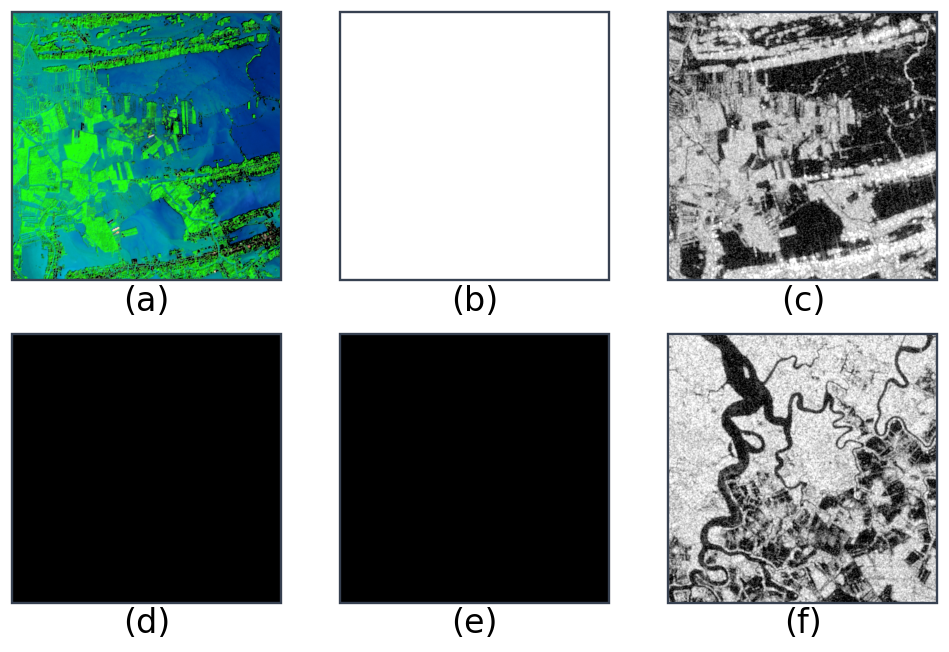

### Gambar 4.2 — Visualisasi contoh channel input pada wilayah Aceh Utara

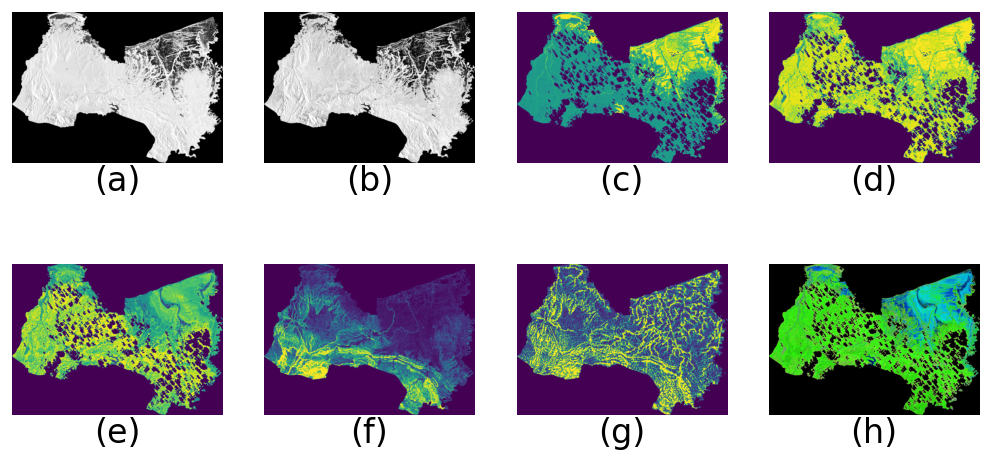

ArtifactSpec(artifact_id='Gambar 4.2', kind='figure', section='4.1.1', title='Visualisasi contoh channel input pada wilayah Aceh Utara', filename='4_1_1_channel_example_aceh_utara.png', legacy_filename=None, priority='required', source_note='')

In [5]:
b411_figure_s2_valid_vs_empty(config)
b411_figure_channel_example(config)

## 4.1.2 Alignment Raster dan Stack Tujuh Channel

### Logika helper 4.1.2

In [6]:
def b412_spec(artifact_id: str):
    return next((spec for spec in ALL_ARTIFACTS if spec.artifact_id == artifact_id))

def b412_table_alignment(config):
    spec = b412_spec('Tabel 4.4')
    rows = []
    layer_names = ['vv_norm.tif', 'vh_norm.tif', 'hue.tif', 'saturation.tif', 'value.tif', 'slope_norm.tif', 'hand_norm.tif']
    for region in REGIONS:
        feature_dir = config.dataset_root / 'features_preprocessed' / region
        ref = raster_metadata(feature_dir / 'vv_norm.tif')
        checks = []
        for name in layer_names + ['stack_7ch.tif']:
            meta = raster_metadata(feature_dir / name)
            checks.append(meta['width'] == ref['width'] and meta['height'] == ref['height'] and (meta['crs'] == ref['crs']) and (meta['transform'] == ref['transform']))
        rows.append({'wilayah': region.replace('_', ' '), 'ukuran_raster': f"{ref['height']} x {ref['width']}", 'resolusi_piksel': f"{abs(ref['pixel_width']):.0f} x {abs(ref['pixel_width']):.0f}", 'crs_proyeksi': b412_epsg_label(ref['crs']), 'status': 'Selaras' if all(checks) else 'Perlu dicek'})
    return notebook_table(config, spec, rows, source='dataset/features_preprocessed/*/*.tif')

def b412_table_stack_layers(config):
    spec = b412_spec('Tabel 4.5')
    region = config.test_region
    stack_path = config.dataset_root / 'features_preprocessed' / region / 'stack_7ch.tif'
    ds = open_dataset(stack_path)
    rows = []
    for idx, channel in enumerate(CHANNELS_7CH, start=1):
        band = ds.GetRasterBand(idx)
        rows.append({'band': idx, 'nama_layer': channel, 'sumber_layer': b412_source_layer_name(channel), 'ukuran_raster': f'{ds.RasterYSize} x {ds.RasterXSize}', 'resolusi_piksel': f'{abs(ds.GetGeoTransform()[1]):.0f} x {abs(ds.GetGeoTransform()[1]):.0f}', 'crs_proyeksi': b412_epsg_label(ds.GetProjection())})
    return notebook_table(config, spec, rows, source=str(stack_path.relative_to(config.root)))

def b412_epsg_label(crs: str) -> str:
    for code in ('32646', '32647', '32747'):
        if code in crs:
            return f'EPSG:{code}'
    return crs

def b412_source_layer_name(channel: str) -> str:
    return {'VV': 'vv_norm.tif', 'VH': 'vh_norm.tif', 'Hue': 'hue.tif', 'Saturation': 'saturation.tif', 'Value': 'value.tif', 'Slope': 'slope_norm.tif', 'HAND': 'hand_norm.tif'}[channel]

### Hasil 4.1.2

In [7]:
b412_table_alignment(config)
b412_table_stack_layers(config)

### Tabel 4.4 — Hasil verifikasi alignment raster multisensor per wilayah

,wilayah,ukuran_raster,resolusi_piksel,crs_proyeksi,status
0,Aceh Besar,8175 x 9662,10 x 10,EPSG:32646,Selaras
1,Aceh Tamiang,7013 x 6210,10 x 10,EPSG:32647,Selaras
2,Aceh Timur,12096 x 8470,10 x 10,EPSG:32647,Selaras
3,Aceh Utara,5824 x 8101,10 x 10,EPSG:32647,Selaras
4,Agam,4961 x 8606,10 x 10,EPSG:32747,Selaras
5,Banda Aceh,1058 x 1166,10 x 10,EPSG:32646,Selaras
6,Bireuen,4275 x 6653,10 x 10,EPSG:32647,Selaras
7,Langsa,1727 x 2407,10 x 10,EPSG:32647,Selaras
8,Pasaman Barat,8117 x 9995,10 x 10,EPSG:32647,Selaras
9,Pidie,9918 x 8311,10 x 10,EPSG:32647,Selaras


### Tabel 4.5 — Verifikasi layer dalam stack_7ch.tif pada wilayah Aceh Utara

,band,nama_layer,sumber_layer,ukuran_raster,resolusi_piksel,crs_proyeksi
0,1,VV,vv_norm.tif,5824 x 8101,10 x 10,EPSG:32647
1,2,VH,vh_norm.tif,5824 x 8101,10 x 10,EPSG:32647
2,3,Hue,hue.tif,5824 x 8101,10 x 10,EPSG:32647
3,4,Saturation,saturation.tif,5824 x 8101,10 x 10,EPSG:32647
4,5,Value,value.tif,5824 x 8101,10 x 10,EPSG:32647
5,6,Slope,slope_norm.tif,5824 x 8101,10 x 10,EPSG:32647
6,7,HAND,hand_norm.tif,5824 x 8101,10 x 10,EPSG:32647


,band,nama_layer,sumber_layer,ukuran_raster,resolusi_piksel,crs_proyeksi
0,1,VV,vv_norm.tif,5824 x 8101,10 x 10,EPSG:32647
1,2,VH,vh_norm.tif,5824 x 8101,10 x 10,EPSG:32647
2,3,Hue,hue.tif,5824 x 8101,10 x 10,EPSG:32647
3,4,Saturation,saturation.tif,5824 x 8101,10 x 10,EPSG:32647
4,5,Value,value.tif,5824 x 8101,10 x 10,EPSG:32647
5,6,Slope,slope_norm.tif,5824 x 8101,10 x 10,EPSG:32647
6,7,HAND,hand_norm.tif,5824 x 8101,10 x 10,EPSG:32647


## 4.2 Label UNOSAT dan Dataset Tile

### Logika helper 4.2

In [8]:
def b42_spec(artifact_id: str):
    return next((spec for spec in ALL_ARTIFACTS if spec.artifact_id == artifact_id))

def b42_tile_stats(config) -> dict[str, dict[str, object]]:
    stats = {}
    tile_root = config.dataset_root / 'tiles' / '7ch' / 'by_region'
    for region in REGIONS:
        total_tile = 0
        valid_tile = 0
        positive_tile = 0
        valid_pixels = 0
        flood_pixels = 0
        water_river_pixels = 0
        s2_valid_pixels = 0
        for path in sorted((tile_root / region).glob('*.npz')):
            total_tile += 1
            tile = load_npz(path)
            valid = np.squeeze(tile['valid_mask']).astype(bool)
            flood = np.squeeze(tile['y']).astype(bool) & valid
            water = np.squeeze(tile.get('water_river_mask', np.zeros_like(valid))).astype(bool) & valid
            s2 = np.squeeze(tile.get('s2_valid_mask', np.zeros_like(valid))).astype(bool) & valid
            valid_count = int(valid.sum())
            flood_count = int(flood.sum())
            valid_pixels += valid_count
            flood_pixels += flood_count
            water_river_pixels += int(water.sum())
            s2_valid_pixels += int(s2.sum())
            if valid_count > 0:
                valid_tile += 1
                if flood_count > 0:
                    positive_tile += 1
        stats[region] = {'split': 'test' if region == config.test_region else 'cv', 'total_tile': total_tile, 'valid_tile': valid_tile, 'positive_tile': positive_tile, 'background_tile': max(valid_tile - positive_tile, 0), 'valid_pixels': valid_pixels, 'flood_pixels': flood_pixels, 'non_flood_pixels': max(valid_pixels - flood_pixels, 0), 'water_river_pixels': water_river_pixels, 's2_valid_pixels': s2_valid_pixels}
    return stats

def b42_label_rows(tile_stats: dict[str, dict[str, object]]) -> list[dict[str, object]]:
    rows = []
    for region in REGIONS:
        row = tile_stats[region]
        valid = to_int(row.get('valid_pixels'))
        flood = to_int(row.get('flood_pixels'))
        water = to_int(row.get('water_river_pixels'))
        rows.append({'wilayah': region.replace('_', ' '), 'piksel_valid': valid, 'piksel_banjir': flood, 'piksel_non_banjir': max(valid - flood, 0), 'water_river_pixels': water})
    return rows

def b42_label_percentage_rows(label_rows: list[dict[str, object]]) -> list[dict[str, object]]:
    rows = []
    for row in label_rows:
        rows.append({'wilayah': row['wilayah'], 'banjir_dalam_valid_pct': fmt_float(pct(to_float(row['piksel_banjir']), to_float(row['piksel_valid'])), 1), 'water_river_dalam_valid_pct': fmt_float(pct(to_float(row['water_river_pixels']), to_float(row['piksel_valid'])), 1), 'rasio_non_banjir': fmt_float(to_float(row['piksel_non_banjir']) / max(to_float(row['piksel_banjir']), 1), 1)})
    return rows

def b42_tile_rows(tile_stats: dict[str, dict[str, object]]) -> list[dict[str, object]]:
    rows = []
    for region in REGIONS:
        row = tile_stats[region]
        total = to_int(row.get('total_tile'))
        valid = to_int(row.get('valid_tile'))
        positive = to_int(row.get('positive_tile'))
        background = to_int(row.get('background_tile'))
        rows.append({'wilayah': region.replace('_', ' '), 'total_tile': total, 'tile_valid': valid, 'tile_positive': positive, 'tile_background': background, 'tile_positive_pct': fmt_float(pct(positive, total), 2), 'tile_background_pct': fmt_float(pct(background, total), 2)})
    return rows

def b42_imbalance_label(flood_pct: float) -> str:
    if flood_pct >= 15:
        return 'banjir relatif dominan'
    if flood_pct >= 5:
        return 'banjir moderat'
    return 'banjir minoritas kuat'

def b42_figure_mask_panel(config):
    spec = b42_spec('Gambar 4.4')
    region = config.test_region
    label_dir = config.dataset_root / 'labels_unosat_rasterized' / region
    flood = read_raster(label_dir / 'label_flood_binary.tif')
    valid = read_raster(label_dir / 'label_valid_mask.tif')
    water = read_raster(label_dir / 'label_water_river_mask.tif')
    panels = [('label_flood_binary', flood, 'Blues'), ('label_valid_mask', valid, 'Greens'), ('label_water_river_mask', water, 'Blues'), ('area flood within valid', flood.astype(bool) & valid.astype(bool), 'Reds')]
    setup_style()
    fig, axes = plt.subplots(1, 4, figsize=(13.6, 3.4))
    for idx, (ax, (title, arr, cmap)) in enumerate(zip(axes, panels)):
        ax.imshow(arr, cmap=cmap, vmin=0, vmax=1)
        ax.text(0.5, -0.08, f'({chr(97 + idx)})', transform=ax.transAxes, ha='center', va='top', fontsize=20)
        ax.axis('off')
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source=f'dataset/labels_unosat_rasterized/{region}/')

def b42_figure_flood_distribution(config, rows):
    spec = b42_spec('Gambar 4.5')
    setup_style()
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.bar([row['wilayah'] for row in rows], [pct(to_float(row['piksel_banjir']), to_float(row['piksel_valid'])) for row in rows], color='#d9822b')
    ax.set_ylabel('Flood pixels dalam valid mask (%)')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source='dataset/preprocessing_summary.csv')

def b42_figure_tile_examples(config):
    spec = b42_spec('Gambar 4.6')
    positive = b42_find_tile(config.dataset_root / 'tiles' / '7ch' / 'by_region' / config.test_region, want_positive=True)
    background = b42_find_tile(config.dataset_root / 'tiles' / '7ch' / 'by_region' / config.test_region, want_positive=False)
    setup_style()
    fig, axes = plt.subplots(2, 4, figsize=(12, 6.2))
    for row_idx, (label, tile_path) in enumerate((('positive', positive), ('background-only', background))):
        tile = load_npz(tile_path)
        x = np.asarray(tile['x'])
        panels = [('VV', normalize_image(x[0]), 'gray'), ('HSV pseudo-RGB', hsv_to_display_rgb(x[2:5]), None), ('HAND', normalize_image(x[6]), 'viridis'), ('Label', np.asarray(tile['y'])[0], 'gray')]
        for col_idx, (ax, (title, arr, cmap)) in enumerate(zip(axes[row_idx], panels)):
            ax.imshow(arr, cmap=cmap, vmin=0 if cmap == 'gray' else None, vmax=1 if cmap == 'gray' else None)
            ax.text(0.5, -0.08, f'({chr(97 + row_idx * 4 + col_idx)})', transform=ax.transAxes, ha='center', va='top', fontsize=20)
            ax.axis('off')
            ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#374151', linewidth=1.4, clip_on=False))
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source='dataset/tiles/7ch/by_region/Aceh_Utara/*.npz')

def b42_find_tile(tile_dir: Path, *, want_positive: bool) -> Path:
    best = None
    best_score = -1.0
    for path in sorted(tile_dir.glob('*.npz')):
        tile = load_npz(path)
        valid = np.asarray(tile['valid_mask']).astype(bool)
        flood = np.asarray(tile['y']).astype(bool) & valid
        positives = int(flood.sum())
        if want_positive and positives <= 0:
            continue
        if not want_positive and positives > 0:
            continue
        score = float(valid.sum()) + positives
        if score > best_score:
            best, best_score = (path, score)
    if best is None:
        return next(tile_dir.glob('*.npz'))
    return best

### Hasil tabel 4.2

In [9]:
tile_stats = b42_tile_stats(config)
label_rows = b42_label_rows(tile_stats)
tile_rows = b42_tile_rows(tile_stats)

notebook_table(config, b42_spec("Tabel 4.6"), label_rows)
notebook_table(config, b42_spec("Tabel 4.7"), b42_label_percentage_rows(label_rows))
notebook_table(config, b42_spec("Tabel 4.8"), tile_rows)

### Tabel 4.6 — Statistik label UNOSAT dan mask per wilayah

,wilayah,piksel_valid,piksel_banjir,piksel_non_banjir,water_river_pixels
0,Aceh Besar,106956513,4966404,101990109,2607154
1,Aceh Tamiang,82307919,3514376,78793543,4407206
2,Aceh Timur,206802875,11748572,195054303,9510741
3,Aceh Utara,102158650,18781032,83377618,12835738
4,Agam,54576695,1054938,53521757,0
5,Banda Aceh,2532433,153775,2378658,75817
6,Bireuen,67149979,3740370,63409609,2439065
7,Langsa,7395290,471267,6924023,740496
8,Pasaman Barat,115359798,1304882,114054916,0
9,Pidie,110864777,6514184,104350593,3026288


### Tabel 4.7 — Statistik label UNOSAT dibandingkan valid mask

,wilayah,banjir_dalam_valid_pct,water_river_dalam_valid_pct,rasio_non_banjir
0,Aceh Besar,4.6,2.4,20.5
1,Aceh Tamiang,4.3,5.4,22.4
2,Aceh Timur,5.7,4.6,16.6
3,Aceh Utara,18.4,12.6,4.4
4,Agam,1.9,0.0,50.7
5,Banda Aceh,6.1,3.0,15.5
6,Bireuen,5.6,3.6,17.0
7,Langsa,6.4,10.0,14.7
8,Pasaman Barat,1.1,0.0,87.4
9,Pidie,5.9,2.7,16.0


### Tabel 4.8 — Distribusi tile positif dan background per wilayah

,wilayah,total_tile,tile_valid,tile_positive,tile_background,tile_positive_pct,tile_background_pct
0,Aceh Besar,518,476,266,210,51.35,40.54
1,Aceh Tamiang,465,358,207,151,44.52,32.47
2,Aceh Timur,1063,890,360,530,33.87,49.86
3,Aceh Utara,493,462,292,170,59.23,34.48
4,Agam,278,248,103,145,37.05,52.16
5,Banda Aceh,16,16,16,0,100.00,0.00
6,Bireuen,303,297,175,122,57.76,40.26
7,Langsa,41,41,35,6,85.37,14.63
8,Pasaman Barat,522,485,216,269,41.38,51.53
9,Pidie,572,468,177,291,30.94,50.87


,wilayah,total_tile,tile_valid,tile_positive,tile_background,tile_positive_pct,tile_background_pct
0,Aceh Besar,518,476,266,210,51.35,40.54
1,Aceh Tamiang,465,358,207,151,44.52,32.47
2,Aceh Timur,1063,890,360,530,33.87,49.86
3,Aceh Utara,493,462,292,170,59.23,34.48
4,Agam,278,248,103,145,37.05,52.16
5,Banda Aceh,16,16,16,0,100.00,0.00
6,Bireuen,303,297,175,122,57.76,40.26
7,Langsa,41,41,35,6,85.37,14.63
8,Pasaman Barat,522,485,216,269,41.38,51.53
9,Pidie,572,468,177,291,30.94,50.87


### Hasil gambar 4.2

### Gambar 4.4 — Visualisasi mask UNOSAT pada wilayah Aceh Utara

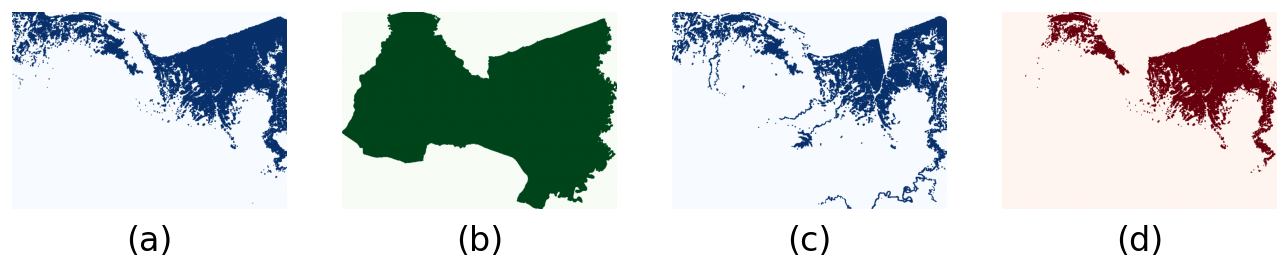

### Gambar 4.5 — Class imbalance label banjir per wilayah

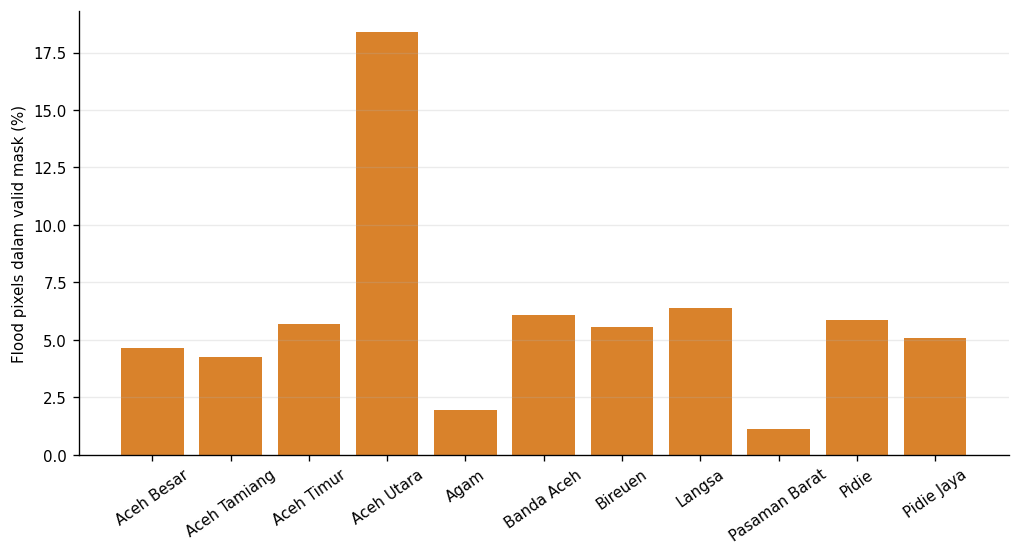

### Gambar 4.6 — Contoh tile positif dan background-only

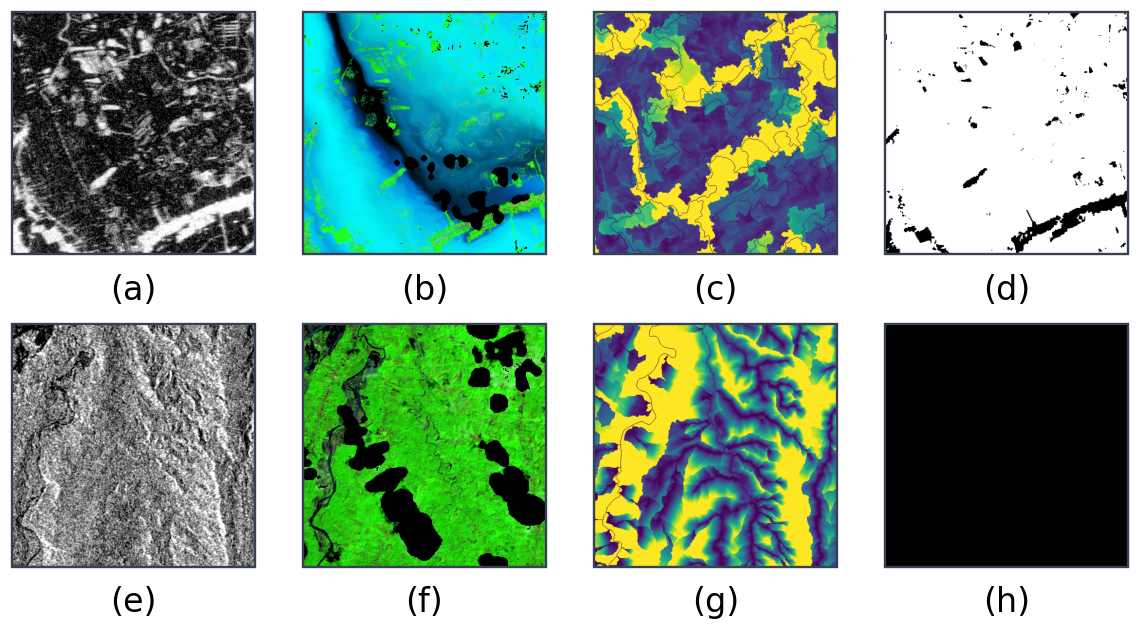

ArtifactSpec(artifact_id='Gambar 4.6', kind='figure', section='4.2', title='Contoh tile positif dan background-only', filename='4_2_positive_background_tile_examples.png', legacy_filename=None, priority='required', source_note='')

In [10]:
b42_figure_mask_panel(config)
b42_figure_flood_distribution(config, label_rows)
b42_figure_tile_examples(config)

## 4.3 Spatial Cross-Validation

### Logika helper 4.3

In [11]:
def b43_spec(artifact_id: str):
    return next((spec for spec in ALL_ARTIFACTS if spec.artifact_id == artifact_id))

def b43_fold_rows(config) -> list[dict[str, object]]:
    summary = read_csv_row_map(config.dataset_root / 'preprocessing_summary.csv')
    test_tiles = to_int(summary[TEST_REGION].get('tile_count'))
    rows = []
    for idx, val_regions in enumerate(SPATIAL_CV_FOLDS):
        train_regions = tuple((region for region in CV_REGIONS if region not in val_regions))
        train_tiles = sum((to_int(summary[region].get('tile_count')) for region in train_regions))
        val_tiles = sum((to_int(summary[region].get('tile_count')) for region in val_regions))
        rows.append({'fold': idx, 'validation_regions': ', '.join(val_regions), 'training_regions': ', '.join(train_regions), 'held_out_final_test': TEST_REGION, 'train_tile_count': train_tiles, 'validation_tile_count': val_tiles, 'final_test_tile_count': test_tiles, 'validation_pct_of_cv_tiles': fmt_float(val_tiles / max(train_tiles + val_tiles, 1) * 100)})
    return rows

def b43_fold_table_rows(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    return [{'fold': row['fold'], 'wilayah_validasi': str(row['validation_regions']).replace('_', ' '), 'wilayah_training': str(row['training_regions']).replace('_', ' '), 'final_test': str(row['held_out_final_test']).replace('_', ' ')} for row in rows]

def b43_figure_fold_counts(config, rows):
    spec = b43_spec('Gambar 4.7')
    labels = [f"Fold {row['fold']}" for row in rows]
    train = [int(row['train_tile_count']) for row in rows]
    val = [int(row['validation_tile_count']) for row in rows]
    test = [int(row['final_test_tile_count']) for row in rows]
    setup_style()
    fig, ax = plt.subplots(figsize=(9, 4.8))
    x = range(len(rows))
    ax.bar([i - 0.25 for i in x], train, width=0.25, label='Train', color='#2563eb')
    ax.bar(x, val, width=0.25, label='Validation', color='#f97316')
    ax.bar([i + 0.25 for i in x], test, width=0.25, label='Final test', color='#16a34a')
    ax.set_xticks(list(x), labels)
    ax.set_ylabel('Jumlah tile')
    ax.set_title('Jumlah tile train, validation, dan final test per fold')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source='scripts/preprocessing_utils.py;dataset/preprocessing_summary.csv')

### Hasil 4.3

### Tabel 4.9 — Pembagian 5-fold spatial cross-validation

,fold,wilayah_validasi,wilayah_training,final_test
0,0,"Pidie, Pidie Jaya","Aceh Besar, Banda Aceh, Aceh Tamiang, Aceh Tim...",Aceh Utara
1,1,"Aceh Besar, Banda Aceh","Pidie, Pidie Jaya, Aceh Tamiang, Aceh Timur, B...",Aceh Utara
2,2,"Aceh Tamiang, Aceh Timur","Pidie, Pidie Jaya, Aceh Besar, Banda Aceh, Bir...",Aceh Utara
3,3,"Bireuen, Langsa","Pidie, Pidie Jaya, Aceh Besar, Banda Aceh, Ace...",Aceh Utara
4,4,"Agam, Pasaman Barat","Pidie, Pidie Jaya, Aceh Besar, Banda Aceh, Ace...",Aceh Utara


### Gambar 4.7 — Jumlah tile train, validation, dan final test per fold

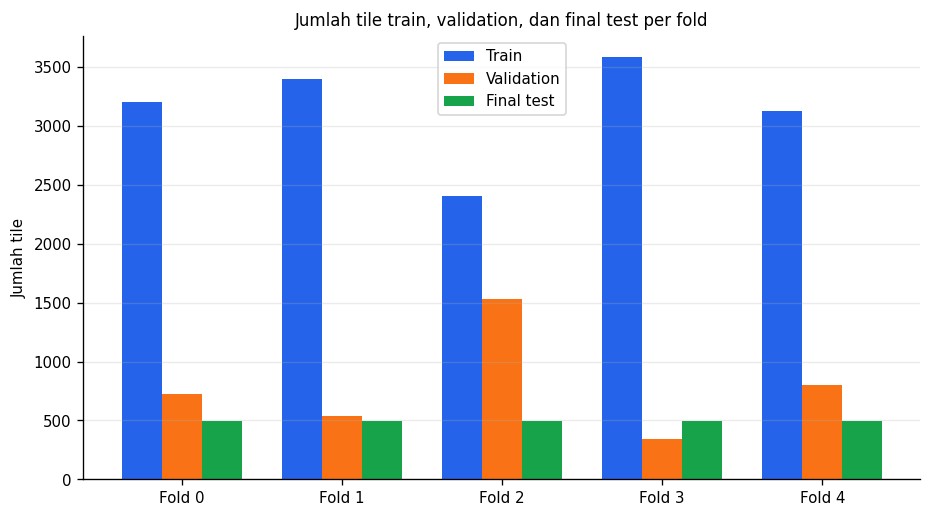

ArtifactSpec(artifact_id='Gambar 4.7', kind='figure', section='4.3', title='Jumlah tile train, validation, dan final test per fold', filename='4_3_fold_tile_counts.png', legacy_filename=None, priority='required', source_note='')

In [12]:
fold_rows = b43_fold_rows(config)
notebook_table(config, b43_spec("Tabel 4.9"), b43_fold_table_rows(fold_rows))
b43_figure_fold_counts(config, fold_rows)

## 4.4 Implementasi dan Pelatihan Model

### Logika helper 4.4.1–4.4.3

In [13]:
def b44_spec(artifact_id: str):
    return next((spec for spec in ALL_ARTIFACTS if spec.artifact_id == artifact_id))

def b44_model_spec_rows(config) -> list[dict[str, object]]:
    configs = {}
    for model in MODEL_KEYS:
        with (config.selected_training_run(model) / 'config.json').open(encoding='utf-8') as handle:
            configs[model] = json.load(handle)
    rows = [{'komponen': 'Jenis model', 'u_net': 'Single encoder-decoder', 'procanet': 'Dual encoder single decoder dengan Progressive Cross-Attention'}, {'komponen': 'Input utama', 'u_net': '7 channel: VV, VH, Hue, Saturation, Value, Slope, HAND', 'procanet': 'Encoder 1: 7 channel penuh; Encoder 2: VV, VH'}, {'komponen': 'Output akhir', 'u_net': '1 channel logit', 'procanet': '1 channel logit'}, {'komponen': 'Base channels', 'u_net': 32, 'procanet': 32}, {'komponen': 'Kedalaman encoder', 'u_net': '4 level', 'procanet': '4 level pada masing-masing encoder'}, {'komponen': 'Channel encoder', 'u_net': '32, 64, 128, 256', 'procanet': '32, 64, 128, 256 pada kedua encoder'}, {'komponen': 'Bottleneck', 'u_net': 'ConvBlock 256 -> 512', 'procanet': 'ConvBlock 256 -> 512 pada tiap encoder, lalu PCAB bottleneck'}, {'komponen': 'Blok konvolusi', 'u_net': 'Conv2d 3x3 + GroupNorm + ReLU, dua kali', 'procanet': 'Conv2d 3x3 + GroupNorm + ReLU, dua kali'}, {'komponen': 'Downsampling', 'u_net': 'MaxPool2d 2x2 pada setiap level encoder', 'procanet': 'MaxPool2d 2x2 pada kedua encoder'}, {'komponen': 'Upsampling/decoder', 'u_net': 'ConvTranspose2d 2x2 + ConvBlock', 'procanet': 'ConvTranspose2d 2x2 + ConvBlock memakai fused skips'}, {'komponen': 'Mekanisme fusi', 'u_net': 'Fusi langsung 7-channel sejak input dan skip connection encoder-decoder', 'procanet': 'ProgressiveCrossAttentionBlock pada skip features dan bottleneck'}]
    rows.extend([{'komponen': 'Checkpoint evaluasi', 'u_net': str(config.selected_training_run('unet').relative_to(config.root) / 'best.pt'), 'procanet': str(config.selected_training_run('procanet').relative_to(config.root) / 'best.pt')}, {'komponen': 'Learning rate checkpoint', 'u_net': configs['unet'].get('lr'), 'procanet': configs['procanet'].get('lr')}, {'komponen': 'Batch size / gradient accumulation', 'u_net': f"{configs['unet'].get('batch_size')} / {configs['unet'].get('gradient_accumulation_steps')}", 'procanet': f"{configs['procanet'].get('batch_size')} / {configs['procanet'].get('gradient_accumulation_steps')}"}])
    return rows

def b44_forward_contract_rows(config) -> list[dict[str, object]]:
    return [{'model': 'U-Net', 'input_uji': '(1, 7, 128, 128)', 'output': '(1, 1, 128, 128)', 'tipe_output': 'Logit', 'jumlah_parameter': 7764193}, {'model': 'ProCANet', 'input_uji': 'Encoder 1: (1, 7, 128, 128); Encoder 2: (1, 2, 128, 128)', 'output': '(1, 1, 128, 128)', 'tipe_output': 'Logit', 'jumlah_parameter': 25052705}]

def b44_grid_summary_rows(config) -> list[dict[str, object]]:
    grouped: dict[tuple[str, str, str], list[dict[str, object]]] = defaultdict(list)
    for model in MODEL_KEYS:
        for metrics_path in sorted((config.runs_root / model).glob('fold_*/grid_*/metrics.csv')):
            match = re.search('grid_lr_(.+)_wd_(.+)$', metrics_path.parent.name)
            fold_match = re.search('fold_(\\d+)$', metrics_path.parent.parent.name)
            if not match or not fold_match:
                continue
            rows = read_csv_rows(metrics_path)
            if not rows:
                continue
            best = max(rows, key=lambda row: to_float(row.get('val_iou')))
            key = (model, match.group(1), match.group(2))
            grouped[key].append({'fold': to_int(fold_match.group(1)), 'best_epoch': to_int(best.get('epoch')), 'best_val_iou': to_float(best.get('val_iou')), 'best_val_dice': to_float(best.get('val_dice')), 'best_val_loss': to_float(best.get('val_loss')), 'epochs_recorded': len(rows), 'source': str(metrics_path.relative_to(config.root))})
    rows = []
    for (model, lr, wd), fold_rows in sorted(grouped.items()):
        ious = [float(row['best_val_iou']) for row in fold_rows]
        dices = [float(row['best_val_dice']) for row in fold_rows]
        losses = [float(row['best_val_loss']) for row in fold_rows]
        best_fold = max(fold_rows, key=lambda row: float(row['best_val_iou']))
        rows.append({'model': MODEL_LABELS[model], 'learning_rate': lr, 'weight_decay': wd, 'folds_completed': len(fold_rows), 'mean_best_val_iou_raw': b44_mean(ious), 'mean_best_val_iou': fmt_float(b44_mean(ious)), 'std_best_val_iou': fmt_float(b44_std(ious)), 'mean_best_val_dice': fmt_float(b44_mean(dices)), 'mean_best_val_loss': fmt_float(b44_mean(losses)), 'best_fold': best_fold['fold'], 'best_fold_epoch': best_fold['best_epoch'], 'best_fold_val_iou': fmt_float(float(best_fold['best_val_iou'])), 'source_files': ';'.join((str(row['source']) for row in sorted(fold_rows, key=lambda item: int(item['fold']))))})
    ranked = []
    for model in MODEL_KEYS:
        label = MODEL_LABELS[model]
        model_rows = [row for row in rows if row['model'] == label]
        model_rows.sort(key=lambda row: float(row['mean_best_val_iou']), reverse=True)
        for rank, row in enumerate(model_rows, start=1):
            ranked.append({'model_rank': rank, **row})
    return ranked

def b44_grid_table_rows(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    by_model_variant = {(str(row['model']), str(row['learning_rate']), str(row['weight_decay'])): row for row in rows}
    variants = [('1e-4', '1e-4'), ('1e-4', '1e-5'), ('5e-5', '1e-4'), ('5e-5', '1e-5'), ('1e-5', '1e-4'), ('1e-5', '1e-5')]
    table_rows = []
    for idx, (lr, wd) in enumerate(variants, start=1):
        unet = by_model_variant.get(('U-Net', lr, wd), {})
        procanet = by_model_variant.get(('ProCANet', lr, wd), {})
        table_rows.append({'id_variasi': idx, 'learning_rate': lr, 'weight_decay': wd, 'u_net_mean_loss': b44_fixed_4(unet.get('mean_best_val_loss')), 'u_net_mean_iou': b44_fixed_4(unet.get('mean_best_val_iou')), 'procanet_mean_loss': b44_fixed_4(procanet.get('mean_best_val_loss')), 'procanet_mean_iou': b44_fixed_4(procanet.get('mean_best_val_iou'))})
    return table_rows

def b44_fixed_4(value: object) -> str:
    if value in (None, ''):
        return ''
    return f'{float(value):.4f}'

def b44_architecture_figure(config, model: str):
    spec = b44_spec('Gambar 4.8' if model == 'unet' else 'Gambar 4.9')
    setup_style()
    if model == 'unet':
        fig, ax = plt.subplots(figsize=(11, 4.2))
        xs = [0.03, 0.18, 0.32, 0.46, 0.6, 0.74, 0.88]
        labels = ['Input\n7 x H x W', 'Encoder\nConvBlock 32\n+ MaxPool', 'Encoder\nConvBlock 64\n+ MaxPool', 'Encoder\nConvBlock 128\n+ MaxPool', 'Encoder\nConvBlock 256\n+ MaxPool', 'Bottleneck\nConvBlock\n256 -> 512', 'Decoder\nUpConv + skip\n512 -> 32']
        for x, label in zip(xs, labels):
            b44_draw_box(ax, x, 0.38, 0.1, 0.16, label, '#e5f0f3')
        b44_draw_box(ax, 0.88, 0.16, 0.1, 0.12, 'Output\n1 logit\nH x W', '#f6dccb')
        for x0, x1 in zip(xs[:-1], xs[1:]):
            b44_arrow(ax, x0 + 0.1, 0.46, x1, 0.46)
        b44_arrow(ax, 0.93, 0.38, 0.93, 0.28)
        for x0, x1, y in ((0.23, 0.83, 0.7), (0.37, 0.79, 0.64), (0.51, 0.75, 0.58), (0.65, 0.74, 0.54)):
            ax.annotate('', xy=(x1, y), xytext=(x0, 0.56), arrowprops={'arrowstyle': '-', 'lw': 0.8, 'linestyle': '--', 'color': '#5f7f7f'})
        ax.text(0.5, 0.86, 'Diagram Implementasi U-Net Aktual', ha='center', fontsize=10)
        ax.text(0.5, 0.76, 'Skip connection dari 4 level encoder ke decoder', ha='center', fontsize=8, color='#496b6b')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
    else:
        fig, ax = plt.subplots(figsize=(11, 5.0))
        ax.text(0.5, 0.92, 'Diagram Implementasi ProCANet Aktual', ha='center', fontsize=10)
        ax.text(0.5, 0.83, 'Encoder 1 menerima 7 channel penuh; Encoder 2 menerima SAR VV/VH', ha='center', fontsize=8)
        xcols = [0.04, 0.18, 0.31, 0.44, 0.57]
        y1, y2 = (0.66, 0.28)
        b44_draw_box(ax, xcols[0], y1, 0.11, 0.12, 'Input Encoder 1\n7ch multisensor', '#e5f0f3')
        b44_draw_box(ax, xcols[0], y2, 0.11, 0.12, 'Input Encoder 2\n2ch SAR VV/VH', '#e5f0f3')
        for idx, x in enumerate(xcols[1:], start=1):
            ch = 32 * 2 ** (idx - 1)
            b44_draw_box(ax, x, y1, 0.1, 0.12, f'Enc1\nConvBlock {ch}\n+ pool', '#dceee3')
            b44_draw_box(ax, x, y2, 0.1, 0.12, f'Enc2\nConvBlock {ch}\n+ pool', '#dceee3')
            b44_draw_box(ax, x + 0.02, 0.47, 0.07, 0.09, f'PCAB\nskip {ch}', '#c8ead7')
        b44_draw_box(ax, 0.72, y1, 0.1, 0.12, 'Bottleneck 1\n256 -> 512', '#f4d6c8')
        b44_draw_box(ax, 0.72, y2, 0.1, 0.12, 'Bottleneck 2\n256 -> 512', '#f4d6c8')
        b44_draw_box(ax, 0.84, 0.46, 0.08, 0.11, 'PCAB\nbottleneck\n512', '#c8ead7')
        b44_draw_box(ax, 0.94, 0.46, 0.07, 0.11, 'Decoder\n+ fused skips\n1 logit', '#f4d6c8')
        for row_y in (y1, y2):
            for x0, x1 in zip(xcols[:-1], xcols[1:]):
                b44_arrow(ax, x0 + 0.11, row_y + 0.06, x1, row_y + 0.06)
            b44_arrow(ax, xcols[-1] + 0.1, row_y + 0.06, 0.72, row_y + 0.06)
        b44_arrow(ax, 0.82, y1 + 0.06, 0.84, 0.52)
        b44_arrow(ax, 0.82, y2 + 0.06, 0.84, 0.52)
        b44_arrow(ax, 0.92, 0.52, 0.94, 0.52)
        ax.text(0.5, 0.12, 'ProgressiveCrossAttentionBlock melakukan fusi skip features dan bottleneck sebelum decoder', ha='center', fontsize=8, color='#496b6b')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source=f'training/models/{model}.py;training/models/blocks.py')

def b44_hyperparameter_figure(config, rows: list[dict[str, object]]):
    spec = b44_spec('Gambar 4.10')
    variants = [('1e-4', '1e-4'), ('1e-4', '1e-5'), ('5e-5', '1e-5'), ('5e-5', '1e-4'), ('1e-5', '1e-4'), ('1e-5', '1e-5')]
    values = {(str(row['model']), str(row['learning_rate']), str(row['weight_decay'])): float(row['mean_best_val_iou']) for row in rows}
    labels = [f'{lr} / {wd}' for lr, wd in variants]
    setup_style()
    fig, ax = plt.subplots(figsize=(11, 5.0))
    x = list(range(len(variants)))
    width = 0.34
    for offset, model in zip((-width / 2, width / 2), ('procanet', 'unet')):
        label = MODEL_LABELS[model]
        series = [values.get((label, lr, wd), 0.0) for lr, wd in variants]
        ax.bar([idx + offset for idx in x], series, width=width, label=label)
    ax.set_xticks(x, labels)
    ax.set_xlabel('Learning rate / weight decay')
    ax.set_ylabel('Mean validation IoU')
    ax.set_ylim(0, 0.7)
    ax.legend(title='Model')
    ax.grid(axis='y', alpha=0.25)
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source='runs/{unet,procanet}/fold_*/grid_*/metrics.csv')

def b44_training_curves_figure(config, metric_paths: dict[str, list], source: str):
    spec = b44_spec('Gambar 4.11')
    fold_rows = {model: [read_csv_rows(path) for path in metric_paths[model]] for model in MODEL_KEYS}
    aggregates = {model: {metric: b44_aggregate_fold_metric(fold_rows[model], metric) for metric in ('train_loss', 'val_loss', 'train_iou', 'val_iou', 'train_dice', 'val_dice', 'lr')} for model in MODEL_KEYS}
    colors = {'unet': '#6A3D9A', 'procanet': '#E66101'}
    setup_style()
    fig, axes = plt.subplots(2, 2, figsize=(11.4, 7.8))
    fig.subplots_adjust(hspace=0.48, wspace=0.34)
    panels = [('Loss', 'train_loss', 'val_loss'), ('IoU', 'train_iou', 'val_iou'), ('Dice/F1', 'train_dice', 'val_dice')]
    for idx, (ax, (title, train_metric, val_metric)) in enumerate(zip(axes.ravel()[:3], panels)):
        for model in MODEL_KEYS:
            color = colors[model]
            b44_plot_aggregate_series(ax, aggregates[model][train_metric], color=color, linestyle='-', label=f'{MODEL_LABELS[model]} train')
            b44_plot_aggregate_series(ax, aggregates[model][val_metric], color=color, linestyle='--', label=f'{MODEL_LABELS[model]} validation')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.grid(alpha=0.25)
        ax.text(0.5, -0.18, f'({chr(97 + idx)})', transform=ax.transAxes, ha='center', va='top', fontsize=20)
    ax_lr = axes.ravel()[3]
    ax_active = ax_lr.twinx()
    lr_handles = []
    active_handles = []
    for model in MODEL_KEYS:
        color = colors[model]
        lr_handle = b44_plot_aggregate_series(ax_lr, aggregates[model]['lr'], color=color, linestyle='-', label=f'{MODEL_LABELS[model]} LR')
        if lr_handle is not None:
            lr_handles.append(lr_handle)
        active_points = aggregates[model]['lr']
        active_handle = ax_active.step([int(point['epoch']) for point in active_points], [int(point['active_folds']) for point in active_points], where='post', color=color, linestyle=':', linewidth=1.3, alpha=0.9, label=f'{MODEL_LABELS[model]} n')[0]
        active_handles.append(active_handle)
    ax_lr.set_xlabel('Epoch')
    ax_lr.set_ylabel('Learning rate')
    ax_lr.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax_lr.grid(alpha=0.25)
    ax_active.set_ylabel('Fold aktif (n)')
    ax_active.set_ylim(0.5, len(SPATIAL_CV_FOLDS) + 0.5)
    ax_active.set_yticks(range(1, len(SPATIAL_CV_FOLDS) + 1))
    ax_active.grid(False)
    ax_lr.text(0.5, -0.18, '(d)', transform=ax_lr.transAxes, ha='center', va='top', fontsize=20)
    axes.ravel()[0].legend(loc='upper right', fontsize=7)
    ax_lr.legend(handles=lr_handles + active_handles, loc='upper right', fontsize=6.5, ncol=2)
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source=source)

def b44_plot_aggregate_series(ax, points: list[dict[str, object]], *, color: str, linestyle: str, label: str):
    visible = [point for point in points if point['mean'] is not None]
    if not visible:
        return None
    epochs = [int(point['epoch']) for point in visible]
    means = [float(point['mean']) for point in visible]
    stds = [float(point['std']) for point in visible]
    line = ax.plot(epochs, means, color=color, linestyle=linestyle, linewidth=1.5, label=label)[0]
    ax.fill_between(epochs, [mean - std for mean, std in zip(means, stds)], [mean + std for mean, std in zip(means, stds)], color=color, alpha=0.1, linewidth=0)
    return line

def b44_aggregate_fold_metric(fold_rows: list[list[dict[str, str]]], metric: str) -> list[dict[str, object]]:
    """Summarize one metric without extending a stopped fold into later epochs."""
    values_by_epoch: dict[int, list[float]] = defaultdict(list)
    for rows in fold_rows:
        observed_epochs: set[int] = set()
        for row in rows:
            epoch = to_int(row.get('epoch'))
            if epoch <= 0:
                continue
            if epoch in observed_epochs:
                raise ValueError(f'epoch duplikat pada metrics.csv: {epoch}')
            observed_epochs.add(epoch)
            value = row.get(metric)
            if value in (None, ''):
                raise ValueError(f'kolom {metric} tidak lengkap pada epoch {epoch}')
            try:
                numeric_value = float(value)
            except (TypeError, ValueError) as exc:
                raise ValueError(f'nilai {metric} tidak valid pada epoch {epoch}') from exc
            if not math.isfinite(numeric_value):
                raise ValueError(f'nilai {metric} tidak valid pada epoch {epoch}')
            values_by_epoch[epoch].append(numeric_value)
    summaries = []
    for epoch, values in sorted(values_by_epoch.items()):
        active_folds = len(values)
        mean = b44_mean(values) if active_folds >= 2 else None
        std = b44_std(values) if active_folds >= 2 else None
        summaries.append({'epoch': epoch, 'active_folds': active_folds, 'mean': mean, 'std': std})
    return summaries

def b44_draw_linear_blocks(ax, labels: list[str], *, color: str) -> None:
    width = 0.14
    gap = 0.055
    x0 = 0.05
    y = 0.42
    for idx, label in enumerate(labels):
        x = x0 + idx * (width + gap)
        b44_draw_box(ax, x, y, width, 0.22, label, color)
        if idx < len(labels) - 1:
            ax.annotate('', xy=(x + width + gap * 0.78, y + 0.11), xytext=(x + width, y + 0.11), arrowprops={'arrowstyle': '->', 'lw': 1.1})
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

def b44_draw_box(ax, x: float, y: float, w: float, h: float, text: str, color: str) -> None:
    patch = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='#374151', linewidth=1.0)
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=9)

def b44_arrow(ax, x0: float, y0: float, x1: float, y1: float) -> None:
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops={'arrowstyle': '->', 'lw': 0.9})

def b44_selected_cv_metric_paths(config) -> tuple[dict[str, dict[str, object]], dict[str, list]]:
    selected_variants = b44_best_complete_cv_variants(b44_grid_summary_rows(config))
    metric_paths: dict[str, list] = {}
    missing_paths = []
    for model in MODEL_KEYS:
        variant = selected_variants[model]
        variant_dir = f"grid_lr_{variant['learning_rate']}_wd_{variant['weight_decay']}"
        paths = [config.runs_root / model / f'fold_{fold}' / variant_dir / 'metrics.csv' for fold in range(len(SPATIAL_CV_FOLDS))]
        metric_paths[model] = paths
        missing_paths.extend((path for path in paths if not path.exists()))
    if missing_paths:
        missing = ', '.join((str(path.relative_to(config.root)) for path in missing_paths))
        raise ValueError(f'metrics.csv konfigurasi terbaik tidak lengkap untuk 5-fold CV: {missing}')
    return (selected_variants, metric_paths)

def b44_best_complete_cv_variants(rows: list[dict[str, object]]) -> dict[str, dict[str, object]]:
    selected = {}
    expected_fold_count = len(SPATIAL_CV_FOLDS)
    for model in MODEL_KEYS:
        candidates = [row for row in rows if row['model'] == MODEL_LABELS[model] and to_int(row.get('folds_completed')) == expected_fold_count]
        if not candidates:
            raise ValueError(f'tidak ada konfigurasi lengkap {expected_fold_count}-fold untuk {MODEL_LABELS[model]}')
        selected[model] = max(candidates, key=lambda row: float(row.get('mean_best_val_iou_raw', row['mean_best_val_iou'])))
    return selected

def b44_metric_paths_source(config, metric_paths: dict[str, list]) -> str:
    return ';'.join((str(path.relative_to(config.root)) for model in MODEL_KEYS for path in metric_paths[model]))

def b44_selected_training_source(config, filename: str) -> str:
    return ';'.join((str((config.selected_training_run(model) / filename).relative_to(config.root)) for model in MODEL_KEYS))

def b44_mean(values: list[float]) -> float:
    return sum(values) / len(values) if values else 0.0

def b44_std(values: list[float]) -> float:
    if len(values) <= 1:
        return 0.0
    mean = b44_mean(values)
    return math.sqrt(sum(((value - mean) ** 2 for value in values)) / (len(values) - 1))

### 4.4.1 Implementasi Arsitektur Model

### Tabel 4.10 — Spesifikasi implementasi arsitektur U-Net dan ProCANet

,komponen,u_net,procanet
0,Jenis model,Single encoder-decoder,Dual encoder single decoder dengan Progressive...
1,Input utama,"7 channel: VV, VH, Hue, Saturation, Value, Slo...","Encoder 1: 7 channel penuh; Encoder 2: VV, VH"
2,Output akhir,1 channel logit,1 channel logit
3,Base channels,32,32
4,Kedalaman encoder,4 level,4 level pada masing-masing encoder
5,Channel encoder,"32, 64, 128, 256","32, 64, 128, 256 pada kedua encoder"
6,Bottleneck,ConvBlock 256 -> 512,"ConvBlock 256 -> 512 pada tiap encoder, lalu P..."
7,Blok konvolusi,"Conv2d 3x3 + GroupNorm + ReLU, dua kali","Conv2d 3x3 + GroupNorm + ReLU, dua kali"
8,Downsampling,MaxPool2d 2x2 pada setiap level encoder,MaxPool2d 2x2 pada kedua encoder
9,Upsampling/decoder,ConvTranspose2d 2x2 + ConvBlock,ConvTranspose2d 2x2 + ConvBlock memakai fused ...


### Tabel 4.11 — Hasil verifikasi forward pass model

,model,input_uji,output,tipe_output,jumlah_parameter
0,U-Net,"(1, 7, 128, 128)","(1, 1, 128, 128)",Logit,7764193
1,ProCANet,"Encoder 1: (1, 7, 128, 128); Encoder 2: (1, 2,...","(1, 1, 128, 128)",Logit,25052705


### Gambar 4.8 — Diagram implementasi U-Net aktual

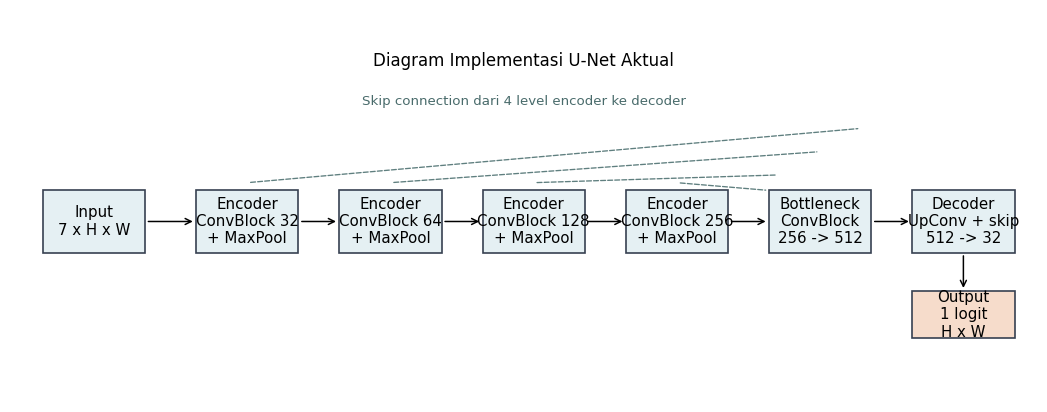

### Gambar 4.9 — Diagram implementasi ProCANet aktual

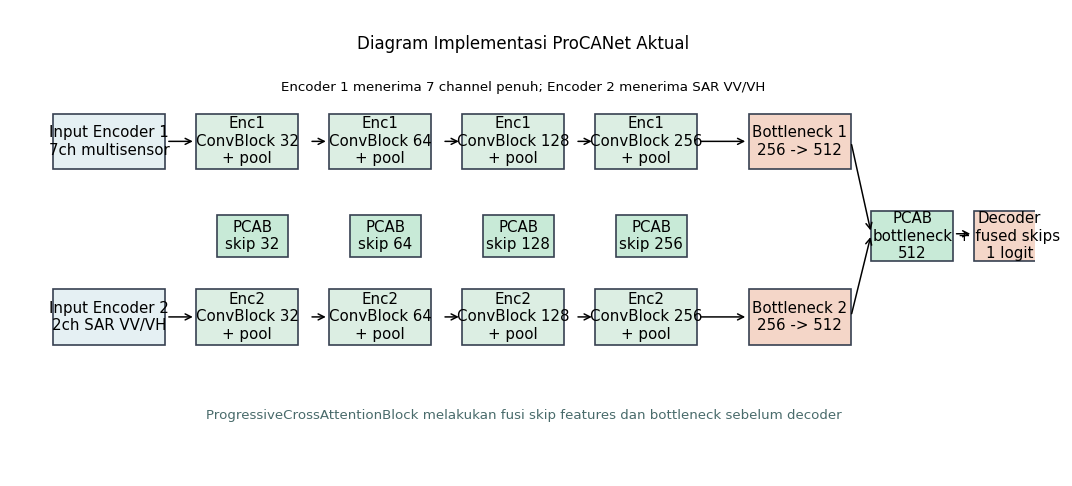

ArtifactSpec(artifact_id='Gambar 4.9', kind='figure', section='4.4.1', title='Diagram implementasi ProCANet aktual', filename='4_4_1_procanet_architecture_diagram.png', legacy_filename=None, priority='required', source_note='')

In [14]:
notebook_table(config, b44_spec("Tabel 4.10"), b44_model_spec_rows(config))
notebook_table(config, b44_spec("Tabel 4.11"), b44_forward_contract_rows(config))
b44_architecture_figure(config, "unet")
b44_architecture_figure(config, "procanet")

### 4.4.2 Grid Search Hyperparameter

### Tabel 4.12 — Hasil grid search hyperparameter U-Net dan ProCANet

,id_variasi,learning_rate,weight_decay,u_net_mean_loss,u_net_mean_iou,procanet_mean_loss,procanet_mean_iou
0,1,1e-4,1e-4,0.7067,0.6306,0.7079,0.6531
1,2,1e-4,1e-5,0.7205,0.6381,0.6714,0.6492
2,3,5e-5,1e-4,0.7704,0.6423,0.7319,0.6409
3,4,5e-5,1e-5,0.7854,0.6373,0.7494,0.6489
4,5,1e-5,1e-4,0.9261,0.6084,0.9569,0.6196
5,6,1e-5,1e-5,0.9892,0.5528,0.8890,0.6183


### Gambar 4.10 — Perbandingan mean validation IoU per kombinasi hyperparameter

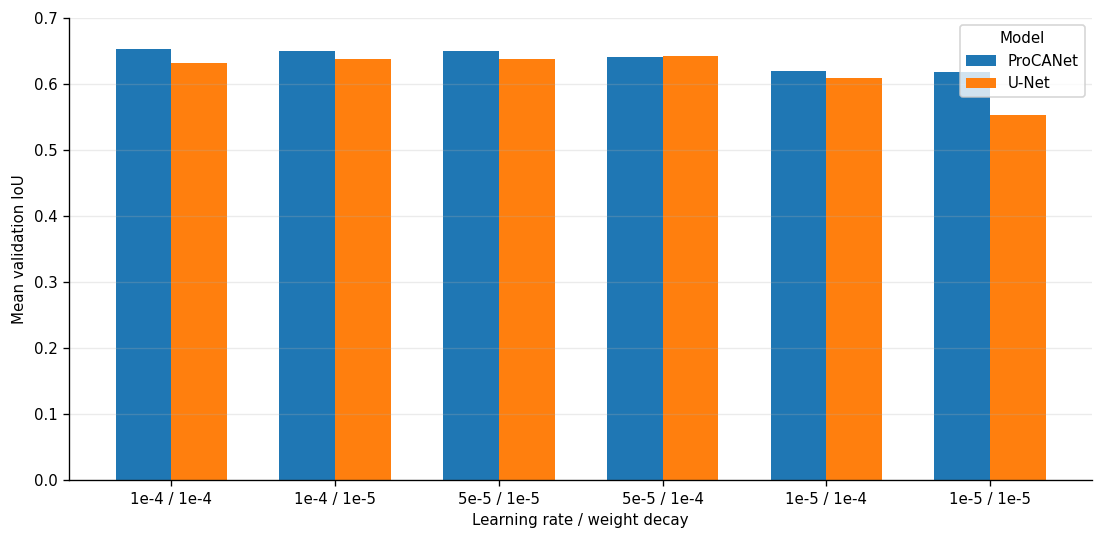

In [15]:
grid_rows = b44_grid_summary_rows(config)
if grid_rows:
    notebook_table(config, b44_spec("Tabel 4.12"), b44_grid_table_rows(grid_rows))
    b44_hyperparameter_figure(config, grid_rows)
else:
    notebook_missing(config, b44_spec("Tabel 4.12"), note="grid search metrics.csv tidak ditemukan")
    notebook_missing(config, b44_spec("Gambar 4.10"), note="grid search metrics.csv tidak ditemukan")

### 4.4.3 Kurva Stabilitas Pelatihan

### Gambar 4.11 — Kurva stabilitas pelatihan pada konfigurasi terbaik

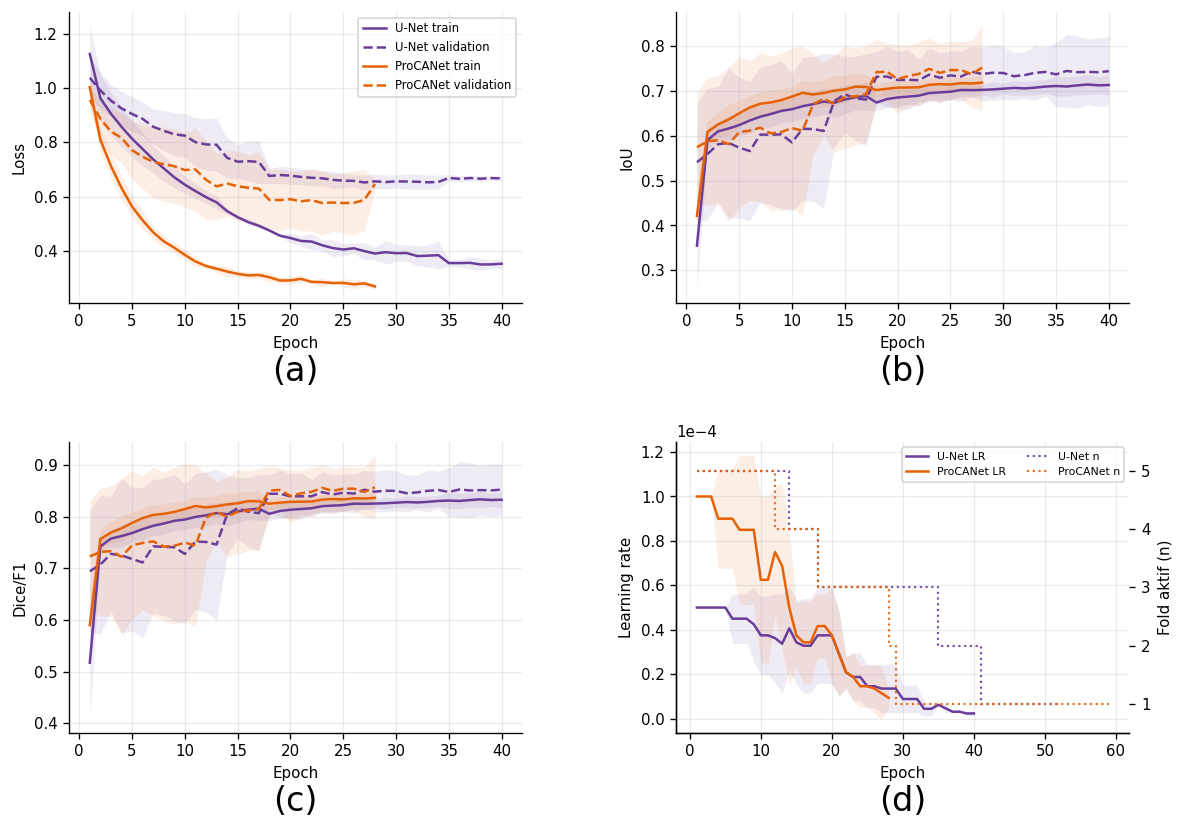

In [16]:
try:
    selected_variants, metric_paths = b44_selected_cv_metric_paths(config)
    metric_source = b44_metric_paths_source(config, metric_paths)
    b44_training_curves_figure(config, metric_paths, metric_source)
except (OSError, ValueError) as exc:
    notebook_missing(config, b44_spec("Gambar 4.11"), note=str(exc))

## 4.5–4.6 Evaluasi dan Visual Segmentasi

### Logika helper 4.5–4.6

In [17]:
b456_TARGET_TILE = 'Aceh_Utara_r001280_c005632.npz'
b456_MOSAIC_BLOCK_SIZE = 512

def b456_spec(artifact_id: str):
    return next((spec for spec in ALL_ARTIFACTS if spec.artifact_id == artifact_id))

def b456_metric_rows(config) -> list[dict[str, object]]:
    rows = []
    label_path = config.dataset_root / 'labels_unosat_rasterized' / config.test_region / 'label_flood_binary.tif'
    for model in MODEL_KEYS:
        metrics_path = config.evaluation_dir(model) / 'metrics.csv'
        if not metrics_path.exists():
            raise FileNotFoundError(f'sumber loss tile tidak ditemukan: {metrics_path}')
        raw_rows = read_csv_rows(metrics_path)
        row = next((item for item in raw_rows if item.get('region') == config.test_region), raw_rows[0] if raw_rows else None)
        if row is None:
            raise ValueError(f'baris metrik tile kosong: {metrics_path}')
        geotiff_dir = config.evaluation_dir(model) / 'geotiff'
        probability_path = geotiff_dir / f'{config.test_region}_probability.tif'
        effective_mask_path = geotiff_dir / f'{config.test_region}_effective_valid_mask.tif'
        stats = b456_mosaic_binary_stats(probability_path, effective_mask_path, label_path, threshold=config.threshold)
        tp = stats['tp']
        tn = stats['tn']
        fp = stats['fp']
        fn = stats['fn']
        evaluated_unique_pixels = stats['evaluated_unique_pixels']
        iou = tp / (tp + fp + fn) if tp + fp + fn else 0.0
        dice = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0
        accuracy = (tp + tn) / evaluated_unique_pixels if evaluated_unique_pixels else 0.0
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        rows.append({'model': MODEL_LABELS[model], 'region': row.get('region', config.test_region), 'loss_tile_rata_rata_batch': fmt_float(to_float(row.get('loss')), 6), 'iou': fmt_float(iou, 6), 'dice': fmt_float(dice, 6), 'accuracy': fmt_float(accuracy, 6), 'precision': fmt_float(precision, 6), 'recall': fmt_float(recall, 6), 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn, 'evaluated_unique_pixels': evaluated_unique_pixels, 'unit_evaluasi': 'piksel unik mosaik dalam effective_valid_mask', 'evaluated_batches': to_int(row.get('batches')), 'source_file': ';'.join((str(path.relative_to(config.root)) for path in (metrics_path, probability_path, effective_mask_path, label_path)))})
    return rows

def b456_mosaic_binary_stats(probability_path: Path, effective_mask_path: Path, label_path: Path, *, threshold: float, block_size: int=b456_MOSAIC_BLOCK_SIZE) -> dict[str, int]:
    paths = (Path(probability_path), Path(effective_mask_path), Path(label_path))
    for path in paths:
        if not path.exists():
            raise FileNotFoundError(f'sumber raster mosaik tidak ditemukan: {path}')
    probability_ds, effective_ds, label_ds = (open_dataset(path) for path in paths)
    b456_validate_same_grid(paths, (probability_ds, effective_ds, label_ds))
    stats = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0, 'evaluated_unique_pixels': 0}
    width = probability_ds.RasterXSize
    height = probability_ds.RasterYSize
    for row in range(0, height, block_size):
        block_height = min(block_size, height - row)
        probability = probability_ds.GetRasterBand(1).ReadAsArray(0, row, width, block_height).astype(np.float32)
        effective = effective_ds.GetRasterBand(1).ReadAsArray(0, row, width, block_height).astype(bool)
        truth = label_ds.GetRasterBand(1).ReadAsArray(0, row, width, block_height).astype(bool)
        invalid_probability = effective & (~np.isfinite(probability) | (probability < 0.0) | (probability > 1.0))
        if invalid_probability.any():
            raise ValueError(f'probabilitas mosaik tidak valid pada effective mask: {probability_path}')
        prediction = probability >= threshold
        stats['tp'] += int((effective & truth & prediction).sum())
        stats['tn'] += int((effective & ~truth & ~prediction).sum())
        stats['fp'] += int((effective & ~truth & prediction).sum())
        stats['fn'] += int((effective & truth & ~prediction).sum())
        stats['evaluated_unique_pixels'] += int(effective.sum())
    return stats

def b456_validate_same_grid(paths: tuple[Path, ...], datasets: tuple[object, ...]) -> None:
    reference = datasets[0]
    reference_grid = (reference.RasterXSize, reference.RasterYSize, reference.GetGeoTransform(), reference.GetProjection())
    for path, dataset in zip(paths[1:], datasets[1:]):
        grid = (dataset.RasterXSize, dataset.RasterYSize, dataset.GetGeoTransform(), dataset.GetProjection())
        if grid != reference_grid:
            raise ValueError(f'grid raster tidak selaras: {paths[0]} dan {path}')

def b456_metric_table_rows(metric_rows: list[dict[str, object]]) -> list[dict[str, object]]:
    return [{'model': row['model'], 'loss_tile_rata_rata_batch': b456_report_float(row['loss_tile_rata_rata_batch'], 6), 'iou': b456_report_float(row['iou'], 6), 'dice_f1': b456_report_float(row['dice'], 6), 'accuracy': b456_report_float(row['accuracy'], 6), 'precision': b456_report_float(row['precision'], 6), 'recall': b456_report_float(row['recall'], 6), 'specificity': b456_report_float(int(row['tn']) / max(int(row['tn']) + int(row['fp']), 1), 6), 'evaluated_unique_pixels': row['evaluated_unique_pixels'], 'unit_evaluasi': row['unit_evaluasi']} for row in metric_rows]

def b456_report_float(value: object, digits: int=3) -> str:
    quant = Decimal('1').scaleb(-digits)
    adjusted = Decimal(str(float(value) + 0.5 * 10 ** (-(digits + 2))))
    return f'{adjusted.quantize(quant, rounding=ROUND_HALF_UP):.{digits}f}'

def b456_confusion_rows(metric_rows: list[dict[str, object]]) -> list[dict[str, object]]:
    rows = []
    for row in metric_rows:
        tp = int(row['tp'])
        tn = int(row['tn'])
        fp = int(row['fp'])
        fn = int(row['fn'])
        rows.append({'model': row['model'], 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn, 'fpr': fmt_float(fp / (fp + tn) if fp + tn else 0.0, 4), 'fnr': fmt_float(fn / (fn + tp) if fn + tp else 0.0, 4), 'evaluated_unique_pixels': row['evaluated_unique_pixels'], 'unit_evaluasi': row['unit_evaluasi']})
    return rows

def b456_figure_metric_comparison(config, rows: list[dict[str, object]]):
    spec = b456_spec('Gambar 4.12')
    metrics = ['iou', 'dice', 'accuracy', 'precision', 'recall']
    labels = [str(row['model']) for row in rows]
    setup_style()
    fig, ax = plt.subplots(figsize=(10, 4.8))
    x = np.arange(len(metrics))
    width = 0.34
    for idx, row in enumerate(rows):
        offset = (idx - (len(rows) - 1) / 2) * width
        bars = ax.bar(x + offset, [float(row[metric]) for metric in metrics], width=width, label=labels[idx])
        ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)
    ax.set_xticks(x, ['iou', 'dice_f1', 'accuracy', 'precision', 'recall'])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Nilai')
    ax.set_xlabel('Metrik')
    ax.set_title(f"Metrik Checkpoint Terbaik Spatial CV pada {config.test_region.replace('_', ' ')}")
    ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.01, 1.0))
    ax.grid(axis='y', alpha=0.25)
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source=b456_metric_source_description(config))

def b456_select_tile(config) -> Path | None:
    tile_dir = config.dataset_root / 'tiles' / '7ch' / 'by_region' / config.test_region
    target = tile_dir / b456_TARGET_TILE
    if target.exists() and all((b456_prediction_path(config, model, target.name).exists() for model in MODEL_KEYS)):
        return target
    best_path = None
    best_score = -1
    for path in sorted(tile_dir.glob('*.npz')):
        if not all((b456_prediction_path(config, model, path.name).exists() for model in MODEL_KEYS)):
            continue
        tile = b456_load_npz(path)
        valid = b456_valid_mask(tile)
        flood = np.squeeze(tile['y']).astype(bool) & valid
        score = int(flood.sum())
        if score > best_score:
            best_path = path
            best_score = score
    return best_path

def b456_prediction_path(config, model: str, tile_name: str) -> Path:
    return config.evaluation_dir(model) / 'predictions' / config.test_region / tile_name

def b456_error_count_rows(tile_path: Path, tile: dict[str, np.ndarray], predictions: dict[str, dict[str, np.ndarray]]) -> list[dict[str, object]]:
    truth = np.squeeze(tile['y']).astype(bool)
    valid = b456_valid_mask(tile)
    rows = []
    for model in MODEL_KEYS:
        prediction = np.squeeze(predictions[model]['prediction']).astype(bool)
        effective = np.squeeze(predictions[model].get('effective_valid_mask', valid)).astype(bool) & valid
        tp = int((truth & prediction & effective).sum())
        tn = int((~truth & ~prediction & effective).sum())
        fp = int((~truth & prediction & effective).sum())
        fn = int((truth & ~prediction & effective).sum())
        iou = tp / (tp + fp + fn) if tp + fp + fn else 0.0
        dice = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0
        rows.append({'model': MODEL_LABELS[model], 'valid_pixels': int(effective.sum()), 'label_positive_pixels': tp + fn, 'predicted_positive_pixels': tp + fp, 'tn': tn, 'tp': tp, 'fp': fp, 'fn': fn})
    return rows

def b456_figure_segmentation_panel(config, tile_path: Path, tile: dict[str, np.ndarray], predictions: dict[str, dict[str, np.ndarray]]):
    spec = b456_spec('Gambar 4.13')
    x = np.asarray(tile['x'], dtype=np.float32)
    truth = np.squeeze(tile['y'])
    panels = [('Kanal Sentinel-1 VV', normalize_image(x[0]), 'gray'), ('Kanal Sentinel-1 VH', normalize_image(x[1]), 'gray'), ('Pseudo-RGB HSV Sentinel-2', hsv_to_display_rgb(x[2:5]), None), ('Slope', normalize_image(x[5]), 'magma'), ('HAND', normalize_image(x[6]), 'viridis'), ('Label UNOSAT', truth, 'Blues'), ('Prediksi U-Net', np.squeeze(predictions['unet']['prediction']), 'Oranges'), ('Prediksi ProCANet', np.squeeze(predictions['procanet']['prediction']), 'Greens')]
    setup_style()
    fig, axes = plt.subplots(2, 4, figsize=(10.5, 5.6))
    for idx, (ax, (title, arr, cmap)) in enumerate(zip(axes.ravel(), panels)):
        ax.imshow(arr, cmap=cmap, vmin=0 if cmap == 'gray' else None, vmax=1 if cmap == 'gray' else None)
        ax.text(0.5, -0.08, f'({chr(97 + idx)})', transform=ax.transAxes, ha='center', va='top', fontsize=20)
        ax.axis('off')
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source=f'{tile_path.relative_to(config.root)};{config.evaluation_source}/predictions/{config.test_region}/{tile_path.name}')

def b456_figure_error_map(config, tile_path: Path, tile: dict[str, np.ndarray], predictions: dict[str, dict[str, np.ndarray]]):
    spec = b456_spec('Gambar 4.14')
    truth = np.squeeze(tile['y']).astype(bool)
    valid = b456_valid_mask(tile)
    cmap = ListedColormap(['#ffffff', '#16a34a', '#dc2626', '#2563eb'])
    labels = [Patch(facecolor='#16a34a', label='TP'), Patch(facecolor='#ffffff', edgecolor='#9ca3af', label='TN'), Patch(facecolor='#dc2626', label='FP'), Patch(facecolor='#2563eb', label='FN')]
    setup_style()
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.2))
    for ax, model in zip(axes, MODEL_KEYS):
        prediction = np.squeeze(predictions[model]['prediction']).astype(bool)
        effective = np.squeeze(predictions[model].get('effective_valid_mask', valid)).astype(bool) & valid
        error = np.zeros(truth.shape, dtype=np.uint8)
        error[truth & prediction & effective] = 1
        error[~truth & prediction & effective] = 2
        error[truth & ~prediction & effective] = 3
        ax.imshow(error, cmap=cmap, vmin=0, vmax=3)
        ax.set_title(MODEL_LABELS[model], fontsize=10)
        ax.axis('off')
    fig.legend(handles=labels, loc='lower center', ncol=4, frameon=False)
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source=f'{tile_path.relative_to(config.root)};{config.evaluation_source}/predictions/{config.test_region}/{tile_path.name}')

def b456_metric_source_description(config) -> str:
    return f'{config.evaluation_source}/metrics.csv;{config.evaluation_source}/geotiff/{config.test_region}_probability.tif;{config.evaluation_source}/geotiff/{config.test_region}_effective_valid_mask.tif;dataset/labels_unosat_rasterized/{config.test_region}/label_flood_binary.tif'

def b456_valid_mask(tile: dict[str, np.ndarray]) -> np.ndarray:
    valid = np.squeeze(tile['valid_mask']).astype(bool)
    feature = np.squeeze(tile.get('feature_valid_mask', valid)).astype(bool)
    return valid & feature

def b456_load_npz(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=False) as payload:
        return {key: payload[key] for key in payload.files}

### 4.5 Evaluasi Final

### Tabel 4.13 — Metrik checkpoint terbaik spatial CV pada wilayah uji Aceh Utara

,model,loss_tile_rata_rata_batch,iou,dice_f1,accuracy,precision,recall,specificity,evaluated_unique_pixels,unit_evaluasi
0,U-Net,0.472528,0.850898,0.919444,0.972336,0.943901,0.896221,0.988611,26305235,piksel unik mosaik dalam effective_valid_mask
1,ProCANet,0.461800,0.853908,0.921198,0.973051,0.949893,0.894185,0.989914,26305235,piksel unik mosaik dalam effective_valid_mask


### Tabel 4.14 — Confusion matrix piksel pada wilayah uji Aceh Utara

,model,tp,tn,fp,fn,fpr,fnr,evaluated_unique_pixels,unit_evaluasi
0,U-Net,4152973,21424542,246824,480896,0.0114,0.1038,26305235,piksel unik mosaik dalam effective_valid_mask
1,ProCANet,4143537,21452796,218570,490332,0.0101,0.1058,26305235,piksel unik mosaik dalam effective_valid_mask


### Gambar 4.12 — Perbandingan metrik checkpoint terbaik spatial CV pada wilayah uji Aceh Utara

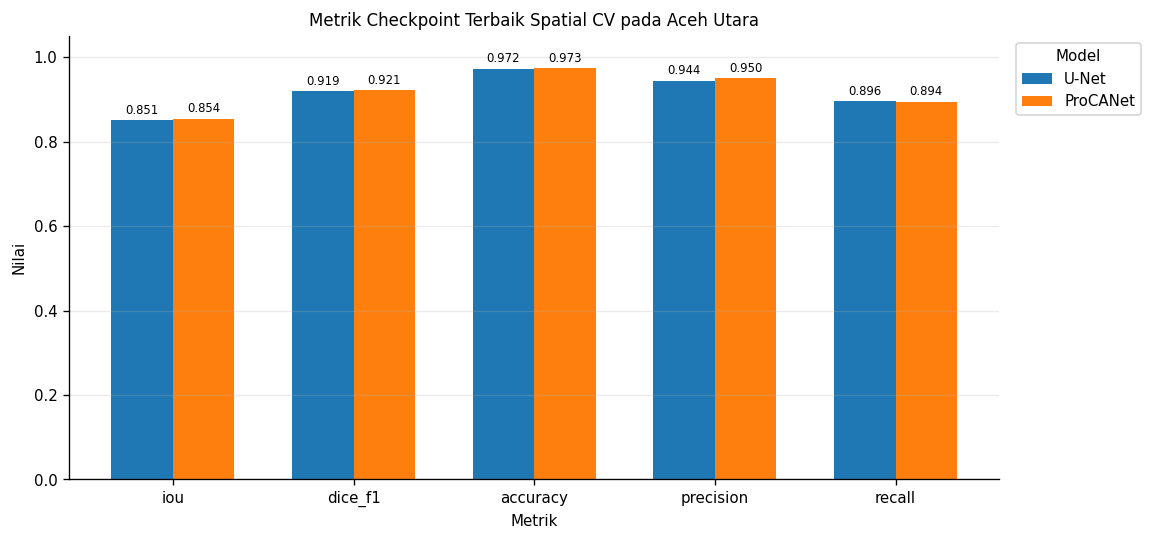

In [18]:
try:
    metric_rows = b456_metric_rows(config)
except (FileNotFoundError, ValueError) as exc:
    metric_rows = []
    notebook_missing(config, b456_spec("Tabel 4.13"), note=str(exc))
    notebook_missing(config, b456_spec("Tabel 4.14"), note=str(exc))
    notebook_missing(config, b456_spec("Gambar 4.12"), note=str(exc))

if metric_rows:
    notebook_table(config, b456_spec("Tabel 4.13"), b456_metric_table_rows(metric_rows))
    notebook_table(config, b456_spec("Tabel 4.14"), b456_confusion_rows(metric_rows))
    b456_figure_metric_comparison(config, metric_rows)

### 4.6 Panel Segmentasi dan Error Map

### Tabel 4.15 — Jumlah piksel error map pada tile Aceh_Utara_r001280_c005632

,model,valid_pixels,label_positive_pixels,predicted_positive_pixels,tn,tp,fp,fn
0,U-Net,262144,247132,234432,13715,233135,1297,13997
1,ProCANet,262144,247132,235195,14619,234802,393,12330


### Gambar 4.13 — Panel input, label, dan prediksi segmentasi pada tile Aceh Utara

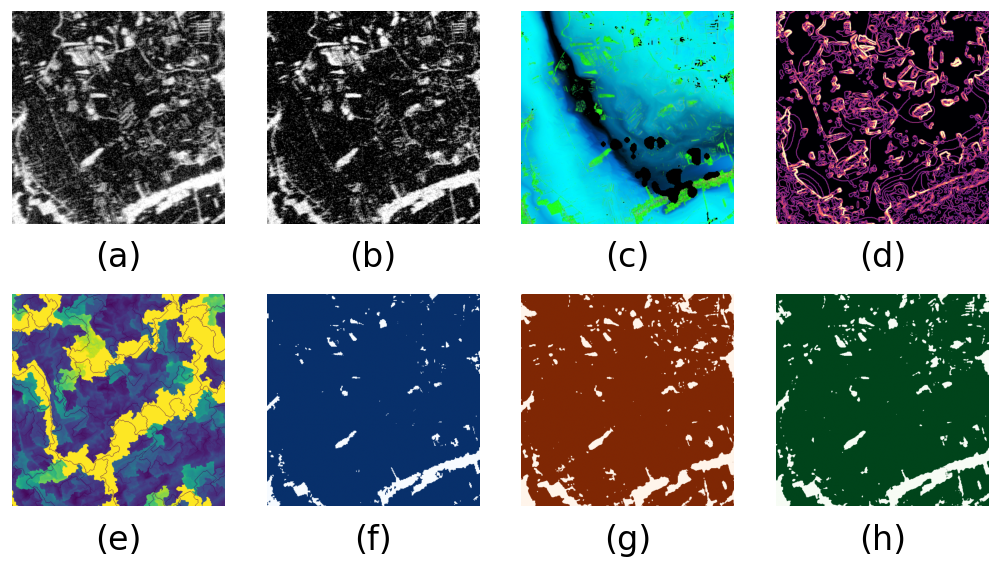

### Gambar 4.14 — Error map TP/FP/FN/TN pada tile Aceh Utara

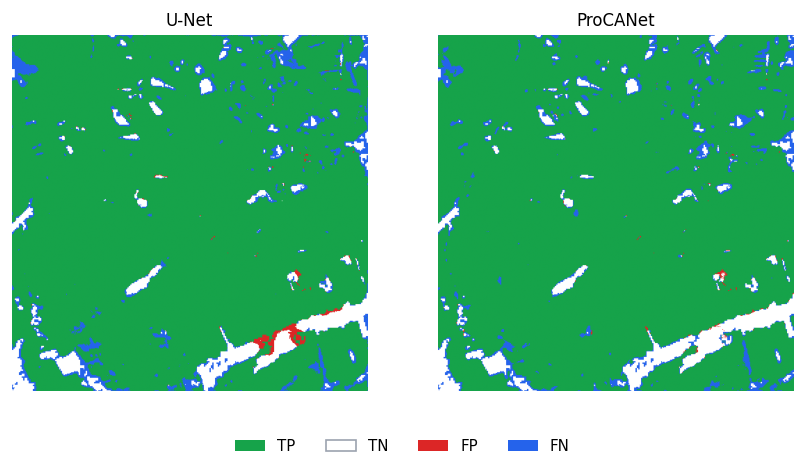

In [19]:
tile_path = b456_select_tile(config)
if tile_path is None:
    note = "tile test dan/atau prediksi checkpoint terbaik spatial CV tidak ditemukan"
    for artifact_id in ("Tabel 4.15", "Gambar 4.13", "Gambar 4.14"):
        notebook_missing(config, b456_spec(artifact_id), note=note)
else:
    tile = b456_load_npz(tile_path)
    predictions = {
        model: b456_load_npz(b456_prediction_path(config, model, tile_path.name))
        for model in MODEL_KEYS
    }
    notebook_table(
        config,
        b456_spec("Tabel 4.15"),
        b456_error_count_rows(tile_path, tile, predictions),
    )
    b456_figure_segmentation_panel(config, tile_path, tile, predictions)
    b456_figure_error_map(config, tile_path, tile, predictions)

## 4.7 Kasus Data Ekstrem

### Logika helper 4.7

In [20]:
b47_SUPPLEMENTARY = (ArtifactSpec('Tambahan 4.7', 'table', '4.7', 'Rincian metrik out-of-fold per wilayah', '4_7_oof_extreme_condition_metrics_by_region.csv', priority='supplementary'),)
b47_OOF_SOURCE = 'runs/oof_extreme_conditions/{micro_metrics.csv,per_region_metrics.csv,selected_tiles.csv,provenance.json}'

def b47_spec(artifact_id: str) -> ArtifactSpec:
    for spec in ALL_ARTIFACTS + b47_SUPPLEMENTARY:
        if spec.artifact_id == artifact_id:
            return spec
    raise KeyError(artifact_id)

def b47_difficult_data_rows(config) -> list[dict[str, object]]:
    tile_stats = b42_tile_stats(config)
    rows = []
    for region in CV_REGIONS:
        summary = tile_stats[region]
        feature_dir = config.dataset_root / 'features_preprocessed' / region
        effective_path = feature_dir / 'feature_valid_mask.tif'
        slope = masked_band_stats(feature_dir / 'slope_degrees.tif', effective_path)
        hand = masked_band_stats(feature_dir / 'hand_meters.tif', effective_path)
        valid = to_int(summary.get('valid_pixels'))
        rows.append({'wilayah': region.replace('_', ' '), 'piksel_valid_tile': valid, 'flood_pct_of_valid': fmt_float(pct(to_int(summary.get('flood_pixels')), valid)), 'water_river_pct_of_valid': fmt_float(pct(to_int(summary.get('water_river_pixels')), valid)), 's2_valid_pct_of_valid': fmt_float(pct(to_int(summary.get('s2_valid_pixels')), valid)), 'mean_slope_degrees': fmt_float(slope['mean']), 'mean_hand_meters': fmt_float(hand['mean'])})
    return sorted(rows, key=lambda row: (float(row['s2_valid_pct_of_valid']), str(row['wilayah'])))

def b47_selected_tile_rows(rows: list[dict[str, str]]) -> list[dict[str, object]]:
    return [{'kondisi': row['condition_label'], 'wilayah': row['region'].replace('_', ' '), 'fold_oof': to_int(row['fold']), 'tile': row['tile'], 'piksel_kondisi': to_int(row['condition_pixels']), 'piksel_efektif': to_int(row['effective_pixels']), 'piksel_banjir': to_int(row['flood_pixels'])} for row in rows]

def b47_metric_value(value: object) -> object:
    if value in (None, '', 'None'):
        return '–'
    return fmt_float(to_float(value), 6)

def b47_micro_metric_rows(rows: list[dict[str, str]]) -> list[dict[str, object]]:
    return [{'kondisi': row['condition_label'], 'model': row['model'], 'piksel_dievaluasi': to_int(row['evaluated_pixels']), 'tp': to_int(row['tp']), 'tn': to_int(row['tn']), 'fp': to_int(row['fp']), 'fn': to_int(row['fn']), 'iou': b47_metric_value(row.get('iou')), 'dice': b47_metric_value(row.get('dice')), 'precision': b47_metric_value(row.get('precision')), 'recall': b47_metric_value(row.get('recall')), 'specificity': b47_metric_value(row.get('specificity')), 'fpr': b47_metric_value(row.get('fpr'))} for row in rows]

def b47_per_region_metric_rows(rows: list[dict[str, str]]) -> list[dict[str, object]]:
    return [{'kondisi': row['condition_label'], 'model': row['model'], 'fold_oof': to_int(row['fold']), 'wilayah': row['region'].replace('_', ' '), 'konfigurasi': row['variant'], 'piksel_kondisi': to_int(row['condition_pixels']), 'piksel_dievaluasi': to_int(row['evaluated_pixels']), 'tp': to_int(row['tp']), 'tn': to_int(row['tn']), 'fp': to_int(row['fp']), 'fn': to_int(row['fn']), 'iou': b47_metric_value(row.get('iou')), 'dice': b47_metric_value(row.get('dice')), 'precision': b47_metric_value(row.get('precision')), 'recall': b47_metric_value(row.get('recall')), 'specificity': b47_metric_value(row.get('specificity')), 'fpr': b47_metric_value(row.get('fpr'))} for row in rows]

def b47_figure_difficult_cases(config, rows: list[dict[str, object]]):
    spec = b47_spec('Gambar 4.15')
    setup_style()
    fig, ax = plt.subplots(figsize=(8.4, 5.0))
    s2 = np.asarray([float(row['s2_valid_pct_of_valid']) for row in rows])
    flood = np.asarray([float(row['flood_pct_of_valid']) for row in rows])
    water = np.asarray([float(row['water_river_pct_of_valid']) for row in rows])
    colors = np.where(s2 <= 1.0, '#6A3D9A', '#E66101')
    ax.scatter(s2, flood, s=35 + water * 12, c=colors, alpha=0.86, edgecolor='white', linewidth=0.8)
    for row, x_value, y_value in zip(rows, s2, flood):
        ax.text(x_value + 1.0, y_value + 0.15, str(row['wilayah']).replace(' ', '_'), fontsize=7)
    ax.axvline(1.0, color='#555555', linestyle='--', linewidth=0.9)
    ax.set_xlabel('Piksel Sentinel-2 valid pada tile valid (%)')
    ax.set_ylabel('Piksel label banjir pada tile valid (%)')
    size_handles = [Line2D([], [], marker='o', linestyle='', markersize=np.sqrt(35 + value * 12), markerfacecolor='#777777', markeredgecolor='white', label=f'{value:g}%') for value in (0.0, 5.0, 10.0)]
    legend = ax.legend(handles=[Patch(facecolor='#6A3D9A', label='Sentinel-2 valid ≤ 1%'), Patch(facecolor='#E66101', label='Sentinel-2 valid > 1%'), Line2D([], [], linestyle='', label='Water/River'), *size_handles], loc='lower right', fontsize=8)
    for text in legend.get_texts():
        if text.get_text() == 'Water/River':
            text.set_weight('bold')
    ax.set_xlim(-3, 103)
    ax.grid(alpha=0.25)
    path = config.figures_dir / spec.filename
    notebook_savefig(fig, path)
    return notebook_figure_result(config, spec, path, source='dataset/preprocessing_summary.csv;dataset/tiles/7ch/by_region')

def b47_figure_extreme_oof(config, artifact_id: str, selected_tiles: list[dict[str, str]], provenance: dict[str, object]):
    condition = {'Gambar 4.16': 's2_empty', 'Gambar 4.17': 'topography_radar_shadow', 'Gambar 4.18': 'permanent_water'}[artifact_id]
    selected = next((row for row in selected_tiles if row.get('condition') == condition), None)
    spec = b47_spec(artifact_id)
    if selected is None:
        return notebook_missing(config, spec, source=b47_OOF_SOURCE, note=f'contoh tile {condition} tidak tersedia')
    path = Path(selected['tile_path'])
    if not path.exists():
        return notebook_missing(config, spec, source=b47_OOF_SOURCE, note=f'tile sumber tidak ditemukan: {path}')
    with np.load(path, allow_pickle=False) as tile:
        x = np.asarray(tile['x'], dtype=np.float32)
        label = np.squeeze(tile['y']).astype(bool)
        effective = np.squeeze(tile['valid_mask']).astype(bool) & np.squeeze(tile['feature_valid_mask']).astype(bool)
        water = np.squeeze(tile['water_river_mask']).astype(bool)
        s2 = np.squeeze(tile['s2_valid_mask']).astype(bool)
        row, col = (int(tile['row'].item()), int(tile['col'].item()))
    thresholds = provenance['radar_percentiles']
    condition_mask = b47_tile_condition(condition, x, effective, label, water, s2, thresholds)
    predictions = {model: b47_prediction_crop(config.runs_root / 'oof_extreme_conditions' / model / f"fold_{selected['fold']}" / 'geotiff' / f"{selected['region']}_prediction.tif", row, col, label.shape) for model in MODEL_KEYS}
    panels = [('Sentinel-1 VV', normalize_image(x[0]), 'gray'), ('Sentinel-1 VH', normalize_image(x[1]), 'gray'), ('Pseudo-RGB HSV', hsv_to_display_rgb(x[2:5]), None), ('Slope', normalize_image(x[5]), 'magma'), ('HAND', normalize_image(x[6]), 'viridis'), ('Mask kondisi', condition_mask, 'Reds'), ('Label UNOSAT', label, 'Blues'), ('Prediksi OOF U-Net', predictions['unet'], 'Oranges'), ('Prediksi OOF ProCANet', predictions['procanet'], 'Purples')]
    setup_style()
    fig, axes = plt.subplots(3, 3, figsize=(9.6, 8.3))
    for index, (ax, (_, image, cmap)) in enumerate(zip(axes.ravel(), panels)):
        binary = cmap in {'gray', 'Reds', 'Blues', 'Oranges', 'Purples'}
        ax.imshow(image, cmap=cmap, vmin=0 if binary else None, vmax=1 if binary else None)
        ax.text(0.04, 0.05, f'({chr(97 + index)})', transform=ax.transAxes, ha='left', va='bottom', fontsize=20, color='black', bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 1.5})
        ax.axis('off')
    fig.subplots_adjust(left=0.015, right=0.985, bottom=0.015, top=0.985, hspace=0.025, wspace=0.025)
    out_path = config.figures_dir / spec.filename
    notebook_savefig(fig, out_path)
    return notebook_figure_result(config, spec, out_path, source=f'{b47_OOF_SOURCE};{path}')

def b47_tile_condition(condition: str, x: np.ndarray, effective: np.ndarray, label: np.ndarray, water: np.ndarray, s2: np.ndarray, thresholds: dict[str, object]) -> np.ndarray:
    if condition == 's2_empty':
        return effective if effective.any() and float(s2[effective].mean()) <= 0.01 else np.zeros_like(effective)
    if condition == 'topography_radar_shadow':
        return effective & (x[5] * 45.0 > 20.0) & (x[6] * 50.0 > 40.0) & ((x[0] <= float(thresholds['p20_vv_norm'])) | (x[1] <= float(thresholds['p20_vh_norm'])))
    return effective & water & ~label

def b47_prediction_crop(path: Path, row: int, col: int, shape: tuple[int, int]) -> np.ndarray:
    ds = gdal.Open(str(path), gdal.GA_ReadOnly)
    if ds is None:
        raise FileNotFoundError(path)
    height, width = shape
    array = np.asarray(ds.GetRasterBand(1).ReadAsArray(col, row, width, height))
    ds = None
    return (array == 1).astype(np.uint8)

### Hasil kondisi data sulit

### Tabel 4.16 — Kondisi data sulit pada wilayah cross-validation

,wilayah,piksel_valid_tile,flood_pct_of_valid,water_river_pct_of_valid,s2_valid_pct_of_valid,mean_slope_degrees,mean_hand_meters
0,Agam,54576695,1.9329,0.0000,0.0000,14.2809,76.1701
1,Langsa,7395290,6.3725,10.0131,0.0000,3.0516,7.2746
2,Aceh Tamiang,82307919,4.2698,5.3545,0.0008,10.3794,68.8762
3,Pasaman Barat,115359798,1.1311,0.0000,0.0022,9.8214,48.9854
4,Aceh Timur,206802875,5.6810,4.5989,53.8605,10.6199,68.6424
5,Aceh Besar,106956513,4.6434,2.4376,80.5364,13.4724,64.7671
6,Banda Aceh,2532433,6.0722,2.9938,83.8523,2.0471,3.1854
7,Bireuen,67149979,5.5702,3.6323,87.9336,11.0642,60.1709
8,Pidie Jaya,34130353,5.0772,3.2262,91.5386,15.1521,73.5360
9,Pidie,110864777,5.8758,2.7297,95.8625,14.9477,73.3117


### Gambar 4.15 — Kondisi data sulit pada wilayah cross-validation

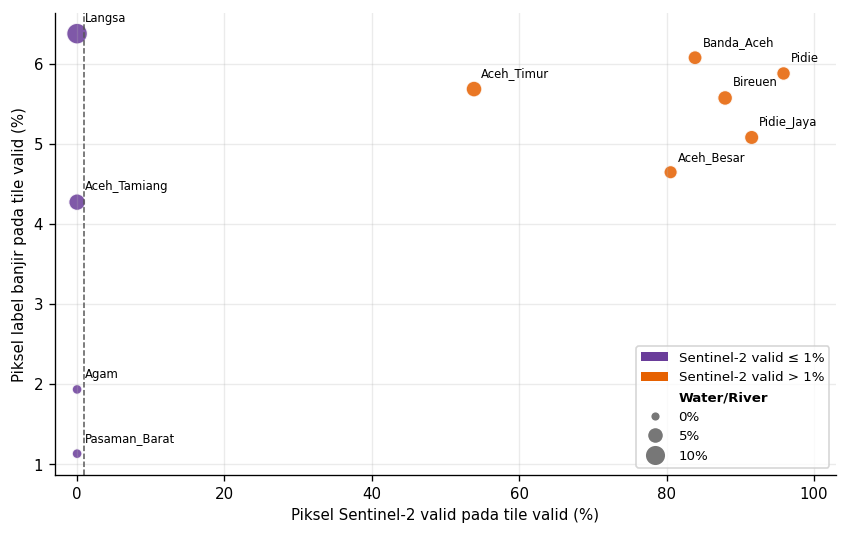

ArtifactSpec(artifact_id='Gambar 4.15', kind='figure', section='4.7', title='Kondisi data sulit pada wilayah cross-validation', filename='4_7_difficult_data_case_studies.png', legacy_filename=None, priority='required', source_note='')

In [21]:
difficult_rows = b47_difficult_data_rows(config)
notebook_table(config, b47_spec("Tabel 4.16"), difficult_rows)
b47_figure_difficult_cases(config, difficult_rows)

### Hasil evaluasi out-of-fold kondisi ekstrem

### Tabel 4.17 — Contoh tile kondisi ekstrem out-of-fold

,kondisi,wilayah,fold_oof,tile,piksel_kondisi,piksel_efektif,piksel_banjir
0,Sentinel-2 kosong/hampir kosong,Aceh Tamiang,2,Aceh_Tamiang_r001024_c003840,262144,262144,147368
1,Topografi sulit/kandidat radar shadow,Aceh Timur,2,Aceh_Timur_r011264_c002048,116892,262144,0
2,Badan air permanen/sungai,Aceh Timur,2,Aceh_Timur_r005632_c007424,52707,190978,47934


### Tabel 4.18 — Metrik out-of-fold pada kondisi data ekstrem

,kondisi,model,piksel_dievaluasi,tp,tn,fp,fn,iou,dice,precision,recall,specificity,fpr
0,Sentinel-2 kosong/hampir kosong,U-Net,83780572,1492703,80267941,1405438,614490,0.424953,0.596445,0.515055,0.708385,0.982792,0.017208
1,Topografi sulit/kandidat radar shadow,U-Net,12356821,853,12348172,4783,3013,0.098624,0.179541,0.151348,0.220641,0.999613,0.000387
2,Badan air permanen/sungai,U-Net,1053769,0,523775,529994,0,–,–,–,–,0.497049,0.502951
3,Sentinel-2 kosong/hampir kosong,ProCANet,83780572,1416051,80494094,1179285,691142,0.430872,0.602251,0.545614,0.672008,0.985561,0.014439
4,Topografi sulit/kandidat radar shadow,ProCANet,12356821,569,12351661,1294,3297,0.110271,0.198639,0.305421,0.147181,0.999895,0.000105
5,Badan air permanen/sungai,ProCANet,1053769,0,598099,455670,0,–,–,–,–,0.567581,0.432419


### Tambahan 4.7 — Rincian metrik out-of-fold per wilayah

,kondisi,model,fold_oof,wilayah,konfigurasi,piksel_kondisi,piksel_dievaluasi,tp,tn,fp,fn,iou,dice,precision,recall,specificity,fpr
0,Sentinel-2 kosong/hampir kosong,U-Net,0,Pidie,grid_lr_5e-5_wd_1e-4,0,0,0,0,0,0,–,–,–,–,–,–
1,Topografi sulit/kandidat radar shadow,U-Net,0,Pidie,grid_lr_5e-5_wd_1e-4,2425467,2314431,41,2314348,1,41,0.493976,0.66129,0.97619,0.5,1.0,0.0
2,Badan air permanen/sungai,U-Net,0,Pidie,grid_lr_5e-5_wd_1e-4,85310,82650,0,64540,18110,0,–,–,–,–,0.780883,0.219117
3,Sentinel-2 kosong/hampir kosong,ProCANet,0,Pidie,grid_lr_1e-4_wd_1e-4,0,0,0,0,0,0,–,–,–,–,–,–
4,Topografi sulit/kandidat radar shadow,ProCANet,0,Pidie,grid_lr_1e-4_wd_1e-4,2425467,2314431,39,2314349,0,43,0.47561,0.644628,1.0,0.47561,1.0,0.0
5,Badan air permanen/sungai,ProCANet,0,Pidie,grid_lr_1e-4_wd_1e-4,85310,82650,0,62124,20526,0,–,–,–,–,0.751652,0.248348
6,Sentinel-2 kosong/hampir kosong,U-Net,0,Pidie Jaya,grid_lr_5e-5_wd_1e-4,0,0,0,0,0,0,–,–,–,–,–,–
7,Topografi sulit/kandidat radar shadow,U-Net,0,Pidie Jaya,grid_lr_5e-5_wd_1e-4,934905,927674,44,927260,7,363,0.10628,0.19214,0.862745,0.108108,0.999992,0.000008
8,Badan air permanen/sungai,U-Net,0,Pidie Jaya,grid_lr_5e-5_wd_1e-4,37930,37930,0,28422,9508,0,–,–,–,–,0.749328,0.250672
9,Sentinel-2 kosong/hampir kosong,ProCANet,0,Pidie Jaya,grid_lr_1e-4_wd_1e-4,0,0,0,0,0,0,–,–,–,–,–,–


### Gambar 4.16 — Kasus OOF Sentinel-2 kosong/hampir kosong

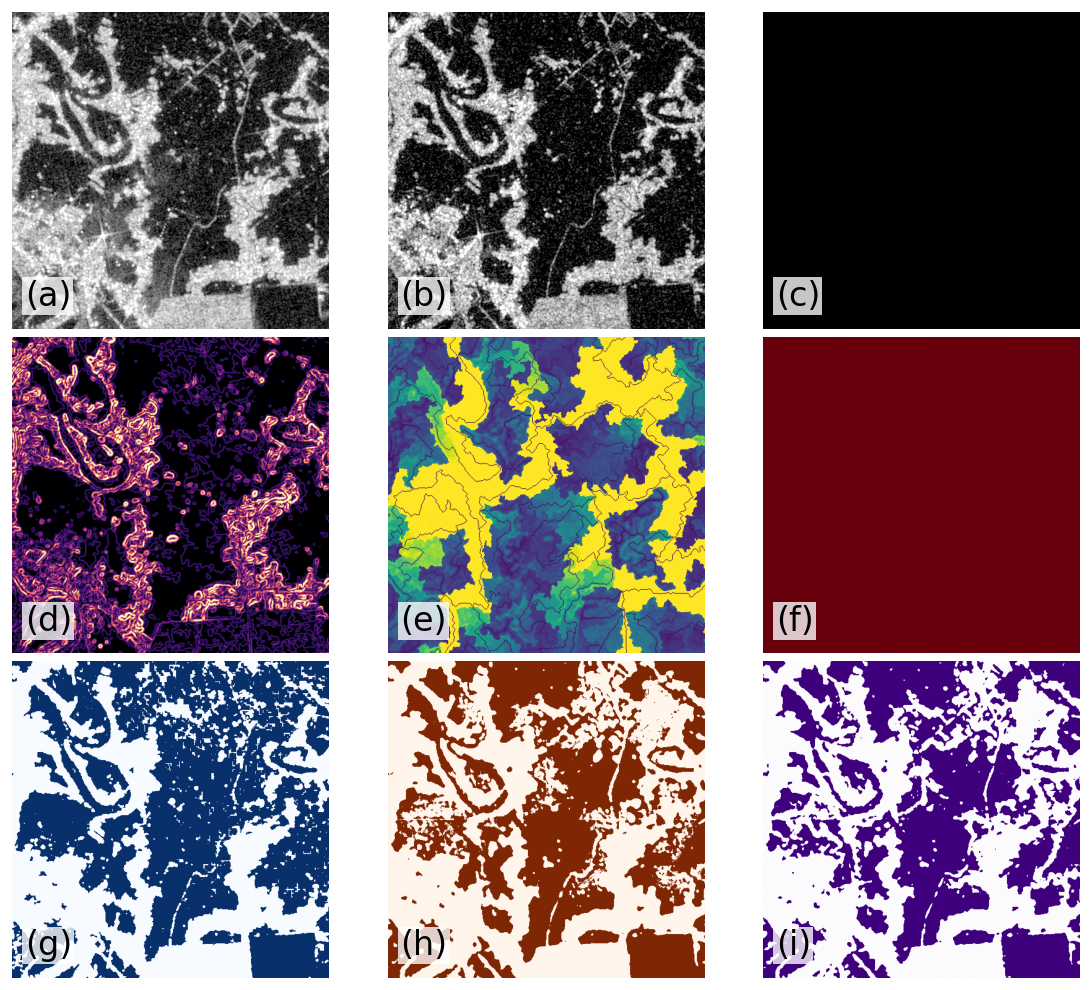

### Gambar 4.17 — Kasus OOF topografi sulit atau kandidat radar shadow

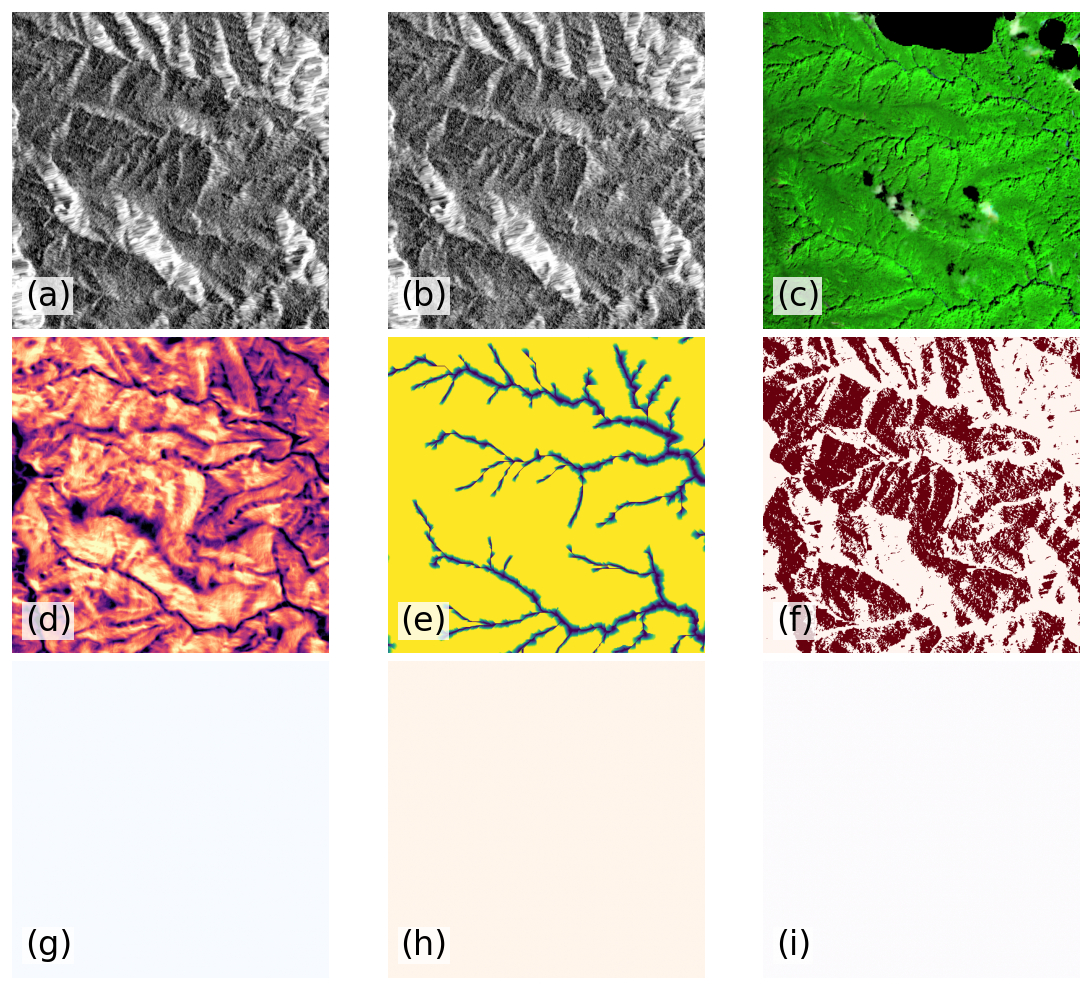

### Gambar 4.18 — Kasus OOF badan air permanen

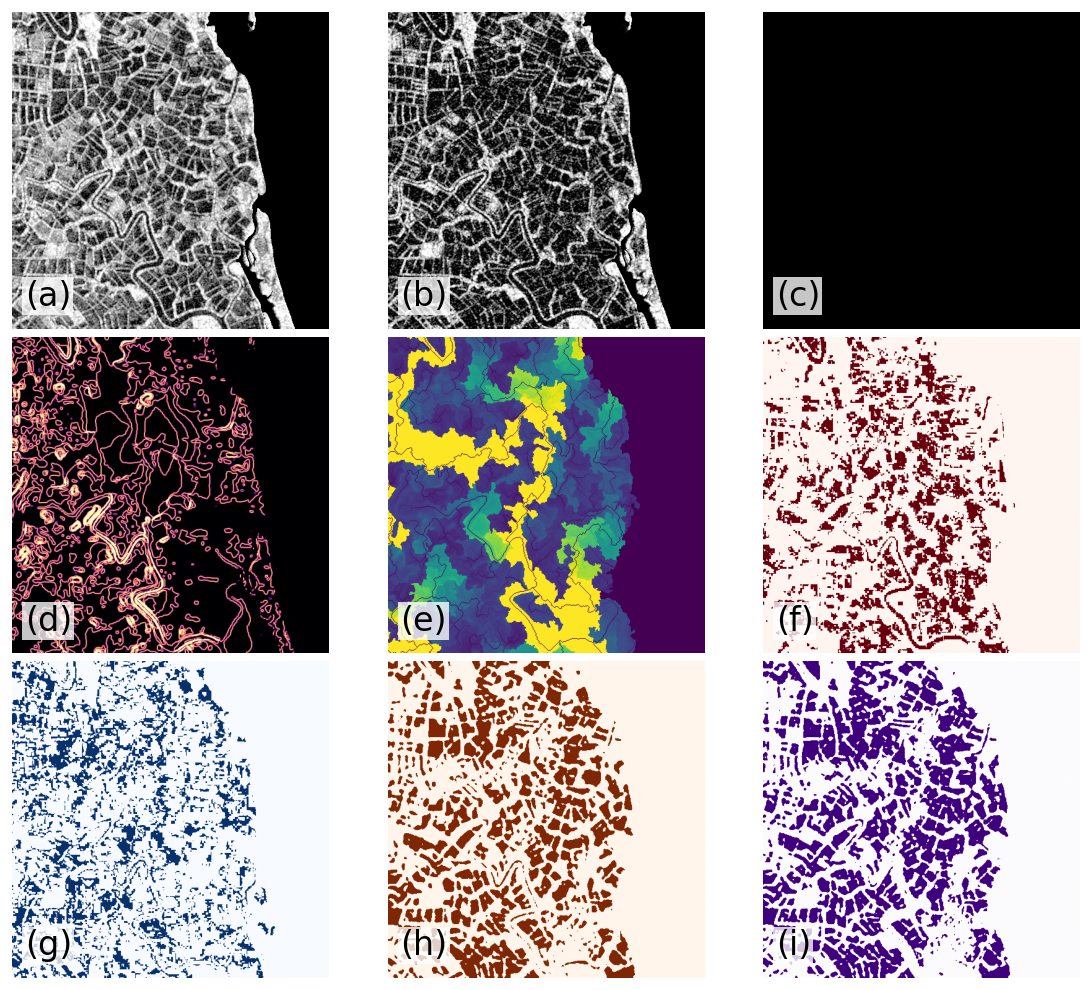

In [22]:
oof_root = config.runs_root / "oof_extreme_conditions"
required_oof = [
    oof_root / name
    for name in ("micro_metrics.csv", "per_region_metrics.csv", "selected_tiles.csv", "provenance.json")
]

if not all(path.exists() for path in required_oof):
    note = "evaluasi OOF belum lengkap; jalankan scripts/evaluate_oof_extreme_conditions.py terlebih dahulu"
    for artifact_id in (
        "Tabel 4.17", "Tabel 4.18", "Tambahan 4.7",
        "Gambar 4.16", "Gambar 4.17", "Gambar 4.18",
    ):
        notebook_missing(config, b47_spec(artifact_id), note=note)
else:
    micro_rows = read_csv_rows(oof_root / "micro_metrics.csv")
    per_region_rows = read_csv_rows(oof_root / "per_region_metrics.csv")
    selected_tiles = read_csv_rows(oof_root / "selected_tiles.csv")
    provenance = json.loads((oof_root / "provenance.json").read_text(encoding="utf-8"))

    notebook_table(config, b47_spec("Tabel 4.17"), b47_selected_tile_rows(selected_tiles))
    notebook_table(config, b47_spec("Tabel 4.18"), b47_micro_metric_rows(micro_rows))
    notebook_table(config, b47_spec("Tambahan 4.7"), b47_per_region_metric_rows(per_region_rows))
    for artifact_id in ("Gambar 4.16", "Gambar 4.17", "Gambar 4.18"):
        b47_figure_extreme_oof(config, artifact_id, selected_tiles, provenance)